# Amazon Grocery Product-to-Product Recommender




### Google Drive Access

In this block, I connect the notebook to Google Drive so the rest of the pipeline can read the saved datasets and artifacts.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Notebook Structure

I split the work into setup, data preparation, feature building, modeling and evaluation


## Methods Used

I combine content features, review-based signals, graph models and hybrid ranking so I can compare simple baselines with stronger recommendation models.


## Environment Setup

In the next blocks, I prepare the runtime and file access so the notebook can run smoothly


In [2]:
import importlib.util
import subprocess
import sys

required_modules = {
    "sentence_transformers": "sentence-transformers",
    "torch_geometric": "torch-geometric",
}
missing_packages = [
    package_name
    for module_name, package_name in required_modules.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *missing_packages])
else:
    print("Required packages already installed. Skipping installation.")


Installing missing packages: torch-geometric


## Imports and Reproducibility

In this block, I import the libraries I need and fix the random state so the rest of the notebook is consistent and reproducible.


In [3]:
import json
import math
import os
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


## Runtime Configuration

In this block, I set the data paths, device choices and model settings so every later step uses the same configuration.


In [4]:
MOUNT_GOOGLE_DRIVE = True
FORCE_REBUILD_CACHE = False

PRODUCT_LIMIT = 12000
MIN_REVIEW_COUNT = 5
MAX_REVIEW_SNIPPETS_PER_PRODUCT = 8
MAX_CHARS_PER_SNIPPET = 300
TEXT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TEXT_BATCH_SIZE = 128
TEXT_EMBED_DIM_FALLBACK = 256
POSITIVE_RATING_THRESHOLD = 4.0
REVIEW_CF_MIN_USER_ITEMS = 2
REVIEW_CF_MAX_USER_ITEMS = 40
REVIEW_CF_TOP_NEIGHBORS = 200
TOPK_VALUES = [1, 5, 10, 20]

TRAIN_EDGE_RATIO = 0.70
VAL_EDGE_RATIO = 0.15
TEST_EDGE_RATIO = 0.15

NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.20
HIDDEN_CHANNELS = 64
TRAIN_HARD_NEGATIVE_RATIO = 0.35
RETRIEVAL_POOL_SIZE = 300
TWO_HOP_EXPANSION = 20
HYBRID_STAGE1_PER_SOURCE = 60
HYBRID_STAGE1_CANDIDATE_POOL = 220
ENABLE_STAGE1_TUNING = True
NUM_STAGE1_TUNING_TRIALS = 10
RERANK_HARD_NEGATIVES_PER_QUERY = 5
RERANK_STAGE1_QUERY_LIMIT = 1500
RERANK_TRAIN_POSITIVE_SAMPLES = 30000
ENABLE_PRODUCT_DIVERSITY_POSTPROCESSING = True
PRODUCT_DIVERSITY_CANDIDATE_POOL = 120
PRODUCT_MAX_SAME_BRAND = 2
PRODUCT_MAX_QUERY_VARIANTS = 1
ENABLE_RANKER_TUNING = True
NUM_RANKER_TUNING_TRIALS = 12
TUNING_QUERY_LIMIT = 400
ENABLE_ENSEMBLE_TUNING = True
NUM_ENSEMBLE_TUNING_TRIALS = 12
ENSEMBLE_POOL_SIZE = 120

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except ImportError:
        print("Google Drive mount skipped because this runtime is not Colab.")

def find_existing_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path("/content") / filename,
        Path("/content/drive/MyDrive/AML_FINAL_PROJECT") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Upload the file to Colab or update the search paths."
    )

REVIEW_PATH = find_existing_file("Grocery_and_Gourmet_Food.json")
META_PATH = find_existing_file("meta_Grocery_and_Gourmet_Food.json")
PROJECT_DIR = REVIEW_PATH.parent
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Review path:", REVIEW_PATH)
print("Meta path:", META_PATH)
print("Artifact directory:", ARTIFACT_DIR)
print("Device:", DEVICE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Review path: /content/drive/MyDrive/AML_FINAL_PROJECT/Grocery_and_Gourmet_Food.json
Meta path: /content/drive/MyDrive/AML_FINAL_PROJECT/meta_Grocery_and_Gourmet_Food.json
Artifact directory: /content/drive/MyDrive/AML_FINAL_PROJECT/artifacts
Device: cuda


## Data Cleaning and Utility Functions

In this block, I defined helper functions for text normalization, metadata parsing, JSON streaming, graph edge deduplication, and neighbor lookup creation. These functions prepare the raw data so the later cleaning, graph construction, and evaluation steps can be handled consistently.


In [5]:
# I normalize raw text fields so titles, descriptions, and review text follow one consistent format.
def normalize_text(value):
    if value is None:
        return ""
    if isinstance(value, list):
        value = " ".join(str(item) for item in value if item)
    elif isinstance(value, dict):
        value = " ".join(f"{k}: {v}" for k, v in value.items())
    value = str(value)
    value = re.sub(r"\s+", " ", value).strip()
    return value

# I extract numeric prices from metadata because the raw field can contain symbols or extra text.
def parse_price(value):
    if value in (None, "", []):
        return np.nan
    text = str(value).replace(",", "")
    match = re.search(r"(\d+(?:\.\d+)?)", text)
    return float(match.group(1)) if match else np.nan

# I convert the raw Amazon rank field into one numeric popularity proxy.
def parse_rank_number(value):
    if value in (None, "", []):
        return np.nan
    if isinstance(value, list):
        value = " ".join(map(str, value))
    match = re.search(r"(\d[\d,]*)", str(value))
    return float(match.group(1).replace(",", "")) if match else np.nan

# I stream the large JSON files line by line so I do not load the full file into memory.
def stream_json_lines(path: Path):
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            yield json.loads(line)

# I treat the product graph as undirected, so I keep only one copy of each edge.
def deduplicate_pairs(pairs):
    deduped = sorted(set(tuple(sorted(map(int, pair))) for pair in pairs if pair[0] != pair[1]))
    return np.array(deduped, dtype=np.int32)

# I build fast node-to-neighbor lookups because the rankers and evaluators query neighbors repeatedly.
def build_neighbor_lookup(pairs, num_nodes):
    lookup = {node_id: set() for node_id in range(num_nodes)}
    for src, dst in pairs:
        lookup[int(src)].add(int(dst))
        lookup[int(dst)].add(int(src))
    return lookup

def text_join(*parts):
    return " ".join(part for part in parts if part).strip()


### Raw Schema Preview

In this block, I preview the raw review and metadata fields so I know what information is available before I clean it.


In [6]:
raw_review_sample = next(stream_json_lines(REVIEW_PATH))
raw_meta_sample = next(stream_json_lines(META_PATH))

def compact_example(value, max_len=120):
    text = normalize_text(value)
    return text[:max_len] + ("..." if len(text) > max_len else "")

review_schema_df = pd.DataFrame(
    {
        "field": sorted(raw_review_sample.keys()),
        "example_value": [compact_example(raw_review_sample[key]) for key in sorted(raw_review_sample.keys())],
    }
)
meta_schema_df = pd.DataFrame(
    {
        "field": sorted(raw_meta_sample.keys()),
        "example_value": [compact_example(raw_meta_sample[key]) for key in sorted(raw_meta_sample.keys())],
    }
)

display(Markdown("#### Raw review record fields"))
display(review_schema_df)
display(Markdown("#### Raw metadata record fields"))
display(meta_schema_df)


#### Raw review record fields

,field,example_value
0,asin,1888861614
1,overall,5.0
2,reviewText,Very pleased with my purchase. Looks exactly like the picture and will look great on my cake. It definitely will sparkle...
3,reviewTime,"06 4, 2013"
4,reviewerID,ALP49FBWT4I7V
5,reviewerName,Lori
6,summary,Love it
7,unixReviewTime,1370304000
8,verified,True


#### Raw metadata record fields

,field,example_value
0,also_buy,
1,also_view,B0000D9MYM B0000D9MYL B00ADHIGBA B00H9OX598 B001LM42GY B001LM5TDY
2,asin,0681727810
3,brand,Ariola Imports
4,category,"Grocery & Gourmet Food Dairy, Cheese & Eggs Cheese Gouda"
5,date,
6,description,BEEMSTER GOUDA CHEESE AGED 18/24 MONTHS Statements regarding dietary supplements have not been evaluated by the FDA and ...
7,feature,
8,fit,
9,imageURL,


## Data Preparation and Cleaning

In this block, I turn the raw review and metadata files into a cleaner product-level table so the downstream models use structured inputs.


In [7]:
# I cache the processed artifacts so I can skip the expensive rebuild step on later runs.
PRODUCT_CACHE = ARTIFACT_DIR / "product_table.pkl"
ALSO_BUY_CACHE = ARTIFACT_DIR / "also_buy_edges.npy"
ALSO_VIEW_CACHE = ARTIFACT_DIR / "also_view_edges.npy"
REVIEW_CF_CACHE = ARTIFACT_DIR / (
    f"review_cf_artifacts_pos{int(POSITIVE_RATING_THRESHOLD * 10)}"
    f"_u{REVIEW_CF_MIN_USER_ITEMS}_{REVIEW_CF_MAX_USER_ITEMS}.pkl"
)

# This function creates the cleaned product table, attaches aggregated review signals, and builds the raw product-product edges.
def build_product_level_dataset():
    if (
        PRODUCT_CACHE.exists()
        and ALSO_BUY_CACHE.exists()
        and ALSO_VIEW_CACHE.exists()
        and not FORCE_REBUILD_CACHE
    ):
        print("Loading cached processed artifacts...")
        product_df = pd.read_pickle(PRODUCT_CACHE)
        also_buy_edges = np.load(ALSO_BUY_CACHE)
        also_view_edges = np.load(ALSO_VIEW_CACHE)
        return product_df, also_buy_edges, also_view_edges

    # First, I aggregate review-level records into product-level statistics.
    print("Pass 1/3: aggregating review-level statistics...")
    review_stats = defaultdict(
        lambda: {
            "review_count": 0,
            "rating_sum": 0.0,
            "verified_sum": 0,
            "review_word_sum": 0,
            "first_review_time": None,
            "last_review_time": None,
        }
    )

    for obj in tqdm(stream_json_lines(REVIEW_PATH)):
        asin = obj.get("asin")
        if not asin:
            continue
        stats = review_stats[asin]
        stats["review_count"] += 1
        stats["rating_sum"] += float(obj.get("overall", 0) or 0)
        stats["verified_sum"] += int(bool(obj.get("verified", False)))
        review_text = normalize_text(obj.get("reviewText"))
        stats["review_word_sum"] += len(review_text.split())
        ts = obj.get("unixReviewTime")
        if ts:
            ts = int(ts)
            stats["first_review_time"] = (
                ts if stats["first_review_time"] is None else min(stats["first_review_time"], ts)
            )
            stats["last_review_time"] = (
                ts if stats["last_review_time"] is None else max(stats["last_review_time"], ts)
            )

    review_stats_df = pd.DataFrame.from_dict(review_stats, orient="index").reset_index()
    review_stats_df = review_stats_df.rename(columns={"index": "asin"})
    review_stats_df["avg_rating"] = review_stats_df["rating_sum"] / review_stats_df["review_count"]
    review_stats_df["verified_ratio"] = review_stats_df["verified_sum"] / review_stats_df["review_count"]
    review_stats_df["avg_review_length"] = (
        review_stats_df["review_word_sum"] / review_stats_df["review_count"]
    )

    # I keep only sufficiently reviewed products and cap the subset size so the Colab run stays manageable.
    candidate_asins = (
        review_stats_df.loc[review_stats_df["review_count"] >= MIN_REVIEW_COUNT]
        .sort_values(["review_count", "avg_rating"], ascending=[False, False])
        .head(PRODUCT_LIMIT)["asin"]
        .tolist()
    )
    candidate_asin_set = set(candidate_asins)

    print(f"Selected {len(candidate_asin_set):,} candidate products after review filtering.")

    # Next, I keep a small set of representative review snippets for each selected product.
    print("Pass 2/3: collecting representative review snippets for the selected products...")
    review_snippets = {asin: [] for asin in candidate_asin_set}
    for obj in tqdm(stream_json_lines(REVIEW_PATH)):
        asin = obj.get("asin")
        if asin not in candidate_asin_set:
            continue
        if len(review_snippets[asin]) >= MAX_REVIEW_SNIPPETS_PER_PRODUCT:
            continue
        snippet = text_join(
            normalize_text(obj.get("summary")),
            normalize_text(obj.get("reviewText")),
        )
        if snippet:
            review_snippets[asin].append(snippet[:MAX_CHARS_PER_SNIPPET])

    # Finally, I load matching metadata and collect also_buy / also_view product links.
    print("Pass 3/3: loading matching metadata and constructing graph edges...")
    meta_rows = []
    for obj in tqdm(stream_json_lines(META_PATH)):
        asin = obj.get("asin")
        if asin not in candidate_asin_set:
            continue

        category_list = obj.get("category", []) or []
        category_text = " > ".join(map(str, category_list))
        description_text = normalize_text(obj.get("description"))
        feature_text = normalize_text(obj.get("feature"))
        details_text = normalize_text(obj.get("details"))

        meta_rows.append(
            {
                "asin": asin,
                "title": normalize_text(obj.get("title")),
                "brand": normalize_text(obj.get("brand")),
                "main_cat": normalize_text(obj.get("main_cat")),
                "category_list": category_list,
                "category_text": category_text,
                "top_category": category_list[0] if len(category_list) > 0 else "",
                "leaf_category": category_list[-1] if len(category_list) > 0 else "",
                "category_depth": len(category_list),
                "description_text": description_text,
                "feature_text": feature_text,
                "details_text": details_text,
                "price": parse_price(obj.get("price")),
                "rank_number": parse_rank_number(obj.get("rank")),
                "also_buy_raw": obj.get("also_buy", []) or [],
                "also_view_raw": obj.get("also_view", []) or [],
                "also_buy_raw_count": len(obj.get("also_buy", []) or []),
                "also_view_raw_count": len(obj.get("also_view", []) or []),
            }
        )

    meta_df = pd.DataFrame(meta_rows).drop_duplicates(subset="asin")
    product_df = meta_df.merge(review_stats_df, on="asin", how="inner")
    product_df["title"] = product_df["title"].replace("", np.nan).fillna(product_df["asin"])
    product_df["brand"] = product_df["brand"].replace("", np.nan).fillna("Unknown Brand")
    product_df["main_cat"] = product_df["main_cat"].replace("", np.nan).fillna("Unknown Category")
    product_df["top_category"] = product_df["top_category"].replace("", np.nan).fillna("Unknown Category")
    product_df["leaf_category"] = product_df["leaf_category"].replace("", np.nan).fillna("Unknown Leaf")
    product_df["review_snippets"] = product_df["asin"].map(
        lambda asin: " ".join(review_snippets.get(asin, []))
    )
    product_df["description_length"] = product_df["description_text"].fillna("").str.split().str.len()

    product_asins = set(product_df["asin"])
    also_buy_pairs = []
    also_view_pairs = []
    for row in product_df.itertuples():
        for dst in row.also_buy_raw:
            if dst in product_asins and dst != row.asin:
                also_buy_pairs.append((row.asin, dst))
        for dst in row.also_view_raw:
            if dst in product_asins and dst != row.asin:
                also_view_pairs.append((row.asin, dst))

    also_buy_pairs = sorted(set(tuple(sorted(pair)) for pair in also_buy_pairs))
    also_view_pairs = sorted(set(tuple(sorted(pair)) for pair in also_view_pairs))
    combined_pairs = sorted(set(also_buy_pairs) | set(also_view_pairs))

    graph = nx.Graph()
    graph.add_nodes_from(product_df["asin"])
    graph.add_edges_from(combined_pairs)

    if graph.number_of_edges() == 0:
        raise ValueError("No graph edges survived filtering. Lower the thresholds or increase PRODUCT_LIMIT.")

    largest_component = max(nx.connected_components(graph), key=len)
    product_df = product_df.loc[product_df["asin"].isin(largest_component)].copy()
    product_df = product_df.sort_values(["review_count", "asin"], ascending=[False, True]).reset_index(drop=True)
    product_df["node_id"] = np.arange(len(product_df))

    asin_to_node = dict(zip(product_df["asin"], product_df["node_id"]))
    also_buy_edges = deduplicate_pairs(
        [(asin_to_node[a], asin_to_node[b]) for a, b in also_buy_pairs if a in asin_to_node and b in asin_to_node]
    )
    also_view_edges = deduplicate_pairs(
        [(asin_to_node[a], asin_to_node[b]) for a, b in also_view_pairs if a in asin_to_node and b in asin_to_node]
    )

    product_df = product_df.drop(columns=["also_buy_raw", "also_view_raw"])

    product_df.to_pickle(PRODUCT_CACHE)
    np.save(ALSO_BUY_CACHE, also_buy_edges)
    np.save(ALSO_VIEW_CACHE, also_view_edges)

    print("Saved processed artifacts to:", ARTIFACT_DIR)
    return product_df, also_buy_edges, also_view_edges

product_df, also_buy_edges, also_view_edges = build_product_level_dataset()
num_nodes = len(product_df)
all_graph_pairs = deduplicate_pairs(np.vstack([also_buy_edges, also_view_edges]))

product_df["title"] = product_df["title"].replace("", np.nan).fillna(product_df["asin"])
product_df["brand"] = product_df["brand"].replace("", np.nan).fillna("Unknown Brand")
product_df["main_cat"] = product_df["main_cat"].replace("", np.nan).fillna("Unknown Category")
product_df["top_category"] = product_df["top_category"].replace("", np.nan).fillna("Unknown Category")
product_df["leaf_category"] = product_df["leaf_category"].replace("", np.nan).fillna("Unknown Leaf")
product_df["description_text"] = product_df["description_text"].fillna("").map(normalize_text)
product_df["feature_text"] = product_df["feature_text"].fillna("").map(normalize_text)
product_df["review_snippets"] = product_df["review_snippets"].fillna("").map(normalize_text)
product_df["category_text"] = product_df["category_text"].fillna("").map(normalize_text)
product_df["description_length"] = product_df["description_text"].str.split().str.len()
product_df["brand_missing_flag"] = product_df["brand"].eq("Unknown Brand").astype(np.int8)
product_df["category_missing_flag"] = product_df["top_category"].eq("Unknown Category").astype(np.int8)
product_df["price_missing_flag"] = product_df["price"].isna().astype(np.int8)
product_df["rank_missing_flag"] = product_df["rank_number"].isna().astype(np.int8)
product_df["description_missing_flag"] = product_df["description_text"].str.len().eq(0).astype(np.int8)
product_df["feature_missing_flag"] = product_df["feature_text"].str.len().eq(0).astype(np.int8)
product_df["review_snippet_missing_flag"] = product_df["review_snippets"].str.len().eq(0).astype(np.int8)

graph = nx.Graph()
graph.add_nodes_from(range(num_nodes))
graph.add_edges_from(map(tuple, all_graph_pairs))

product_df["graph_degree"] = (
    pd.Series(dict(graph.degree()))
    .reindex(range(num_nodes))
    .fillna(0)
    .astype(int)
    .values
)
product_df["first_review_date"] = pd.to_datetime(product_df["first_review_time"], unit="s", errors="coerce")
product_df["last_review_date"] = pd.to_datetime(product_df["last_review_time"], unit="s", errors="coerce")
product_df["first_review_year"] = product_df["first_review_date"].dt.year

print(f"Final products in largest connected component: {num_nodes:,}")
print(f"also_buy edges: {len(also_buy_edges):,}")
print(f"also_view edges: {len(also_view_edges):,}")


Loading cached processed artifacts...
Final products in largest connected component: 11,295
also_buy edges: 122,614
also_view edges: 36,271


## Exploratory Data Analysis

In these blocks, I examine the cleaned data so I can understand its scale, quality, and graph structure before modeling.


In [8]:
dataset_summary = pd.DataFrame(
    {
        "metric": [
            "Products kept after filtering",
            "also_buy edges",
            "also_view edges",
            "Combined graph density",
            "Average degree",
            "Median review count",
            "Average rating",
        ],
        "value": [
            num_nodes,
            len(also_buy_edges),
            len(also_view_edges),
            nx.density(graph),
            np.mean([degree for _, degree in graph.degree()]),
            product_df["review_count"].median(),
            product_df["avg_rating"].mean(),
        ],
    }
)

missingness = (
    product_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

column_role_df = pd.DataFrame(
    [
        ("asin", "identifier", "join reviews to metadata and display examples"),
        ("title, brand, category_text", "metadata text", "content similarity and content-based recommendation"),
        ("description_text, feature_text", "metadata text", "semantic product understanding"),
        ("review_snippets", "review text", "customer-language product representation"),
        ("review_count, avg_rating, verified_ratio", "review aggregates", "quality, popularity, and reliability signals"),
        ("price, rank_number", "numeric metadata", "purchase context and popularity proxy"),
        ("also_buy, also_view", "graph edges", "product-to-product relationships"),
        ("reviewerID positive interactions", "behavioral signal", "review-CF and behavioral product similarity"),
    ],
    columns=["column_or_group", "role", "how_used"],
)

data_quality_summary = pd.DataFrame(
    {
        "check": [
            "Missing titles after cleaning",
            "Unknown brands after cleaning",
            "Unknown top categories after cleaning",
            "Missing prices",
            "Missing rank numbers",
            "Missing descriptions",
            "Missing feature bullets",
            "Missing review snippets",
            "Duplicate ASINs",
            "Products with zero graph degree",
        ],
        "count": [
            int(product_df["title"].isna().sum()),
            int(product_df["brand_missing_flag"].sum()),
            int(product_df["category_missing_flag"].sum()),
            int(product_df["price_missing_flag"].sum()),
            int(product_df["rank_missing_flag"].sum()),
            int(product_df["description_missing_flag"].sum()),
            int(product_df["feature_missing_flag"].sum()),
            int(product_df["review_snippet_missing_flag"].sum()),
            int(product_df["asin"].duplicated().sum()),
            int((product_df["graph_degree"] == 0).sum()),
        ],
    }
)
data_quality_summary["fraction_of_products"] = data_quality_summary["count"] / max(len(product_df), 1)

display(dataset_summary)
display(Markdown("### Column groups and how they are used"))
display(column_role_df)
display(product_df.head(3))
display(Markdown("### Missingness before final model preprocessing"))
display(missingness.head(15))
display(Markdown("### Data quality checks after cleaning"))
display(data_quality_summary)


,metric,value
0,Products kept after filtering,11295.000000
1,also_buy edges,122614.000000
2,also_view edges,36271.000000
3,Combined graph density,0.002193
4,Average degree,24.764055
5,Median review count,142.000000
6,Average rating,4.334547


### Column groups and how they are used

,column_or_group,role,how_used
0,asin,identifier,join reviews to metadata and display examples
1,"title, brand, category_text",metadata text,content similarity and content-based recommendation
2,"description_text, feature_text",metadata text,semantic product understanding
3,review_snippets,review text,customer-language product representation
4,"review_count, avg_rating, verified_ratio",review aggregates,"quality, popularity, and reliability signals"
5,"price, rank_number",numeric metadata,purchase context and popularity proxy
6,"also_buy, also_view",graph edges,product-to-product relationships
7,reviewerID positive interactions,behavioral signal,review-CF and behavioral product similarity


,asin,title,brand,main_cat,category_list,category_text,top_category,leaf_category,category_depth,description_text,feature_text,details_text,price,rank_number,also_buy_raw_count,also_view_raw_count,review_count,rating_sum,verified_sum,review_word_sum,first_review_time,last_review_time,avg_rating,verified_ratio,avg_review_length,review_snippets,description_length,node_id,brand_missing_flag,category_missing_flag,price_missing_flag,rank_missing_flag,description_missing_flag,feature_missing_flag,review_snippet_missing_flag,graph_degree,first_review_date,last_review_date,first_review_year
0,B00BUKL666,"KIND Bars, Dark Chocolate Nuts &amp; Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery,"[Grocery & Gourmet Food, Snack Foods, Bars, Nut Bars]",Grocery & Gourmet Food > Snack Foods > Bars > Nut Bars,Grocery & Gourmet Food,Nut Bars,4,"These bars are where our journey started and it was simple: whole ingredients like nuts, mixed with fruits and spices bound together wit...",,"Product Dimensions: : 6.8 x 6.1 x 2.3 inches ; 1.05 pounds Shipping Weight:: 1.2 pounds ( Domestic Shipping: : Currently, item can be sh...",13.67,18.0,95,0,11526,52055.0,10461,269994,1244332800,1531180800,4.516311,0.907600,23.424779,"Nice snack that lasts! This bar has cranberries, almonds, and macadamia nuts (NOT bits and pieces!) as their main ingredients, in a soft...",240,0,0,0,0,0,0,1,0,15,2009-06-07,2018-07-10,2009
1,B00542YXFW,"Davidson's Tea Bulk, Anise Seed, 16-Ounce Bag",Davidson's Tea,Grocery,"[Grocery & Gourmet Food, Beverages, Coffee, Tea & Cocoa, Tea, Matcha]","Grocery & Gourmet Food > Beverages > Coffee, Tea & Cocoa > Tea > Matcha",Grocery & Gourmet Food,Matcha,5,"Mild, but round and full licorice flavor and aroma. Anise seeds*. (*denotes organic) Statements regarding dietary supplements have not b...",,"Shipping Weight:: 1.1 pounds ( Domestic Shipping: : Currently, item can be shipped only within the U.S. and to APO/FPO addresses. For AP...",15.00,100853.0,95,0,9083,38357.0,8691,400523,1198886400,1529539200,4.222944,0.956842,44.095893,A Great Find! Davidson's bulk Keemun tea can't be beat! Great taste and good price -- especially for organic tea. Packaging is simple an...,39,1,0,0,0,0,0,1,0,26,2007-12-29,2018-06-21,2007
2,B008QMX2SG,"Kind Bars, Madagascar Vanilla Almond, Gluten Free, Low Sugar, 1.4oz",KIND,Grocery,"[Grocery & Gourmet Food, Snack Foods, Bars, Nut Bars]",Grocery & Gourmet Food > Snack Foods > Bars > Nut Bars,Grocery & Gourmet Food,Nut Bars,4,"These bars are where our journey started and it was simple: whole ingredients like nuts, mixed with fruits and spices bound together wit...",,"Product Dimensions: : 2 x 4 x 6 inches ; 1 pounds Shipping Weight:: 1.2 pounds ( Domestic Shipping: : Currently, item can be shipped onl...",14.79,2949.0,95,0,8903,40278.0,8100,202507,1288051200,1531699200,4.524093,0.909806,22.745928,"love them! My family devoured this batch and I'm buying more. They taste nutty and chocolatey, and have protein in them and stop the aft...",205,2,0,0,0,0,0,1,0,20,2010-10-26,2018-07-16,2010


### Missingness before final model preprocessing

,column,missing_fraction
0,price,0.234883
1,rank_number,0.021160
2,asin,0.000000
3,main_cat,0.000000
4,category_list,0.000000
5,title,0.000000
6,brand,0.000000
7,top_category,0.000000
8,category_text,0.000000
9,leaf_category,0.000000


### Data quality checks after cleaning

,check,count,fraction_of_products
0,Missing titles after cleaning,0,0.000000
1,Unknown brands after cleaning,52,0.004604
2,Unknown top categories after cleaning,0,0.000000
3,Missing prices,2653,0.234883
4,Missing rank numbers,239,0.021160
5,Missing descriptions,1136,0.100575
6,Missing feature bullets,9511,0.842054
7,Missing review snippets,0,0.000000
8,Duplicate ASINs,0,0.000000
9,Products with zero graph degree,0,0.000000


### Missingness, Categories, Brands, and Graph Edges

In this block, I inspect missing fields, category mix, brand mix, and edge types so I can see where the dataset is strong or sparse.


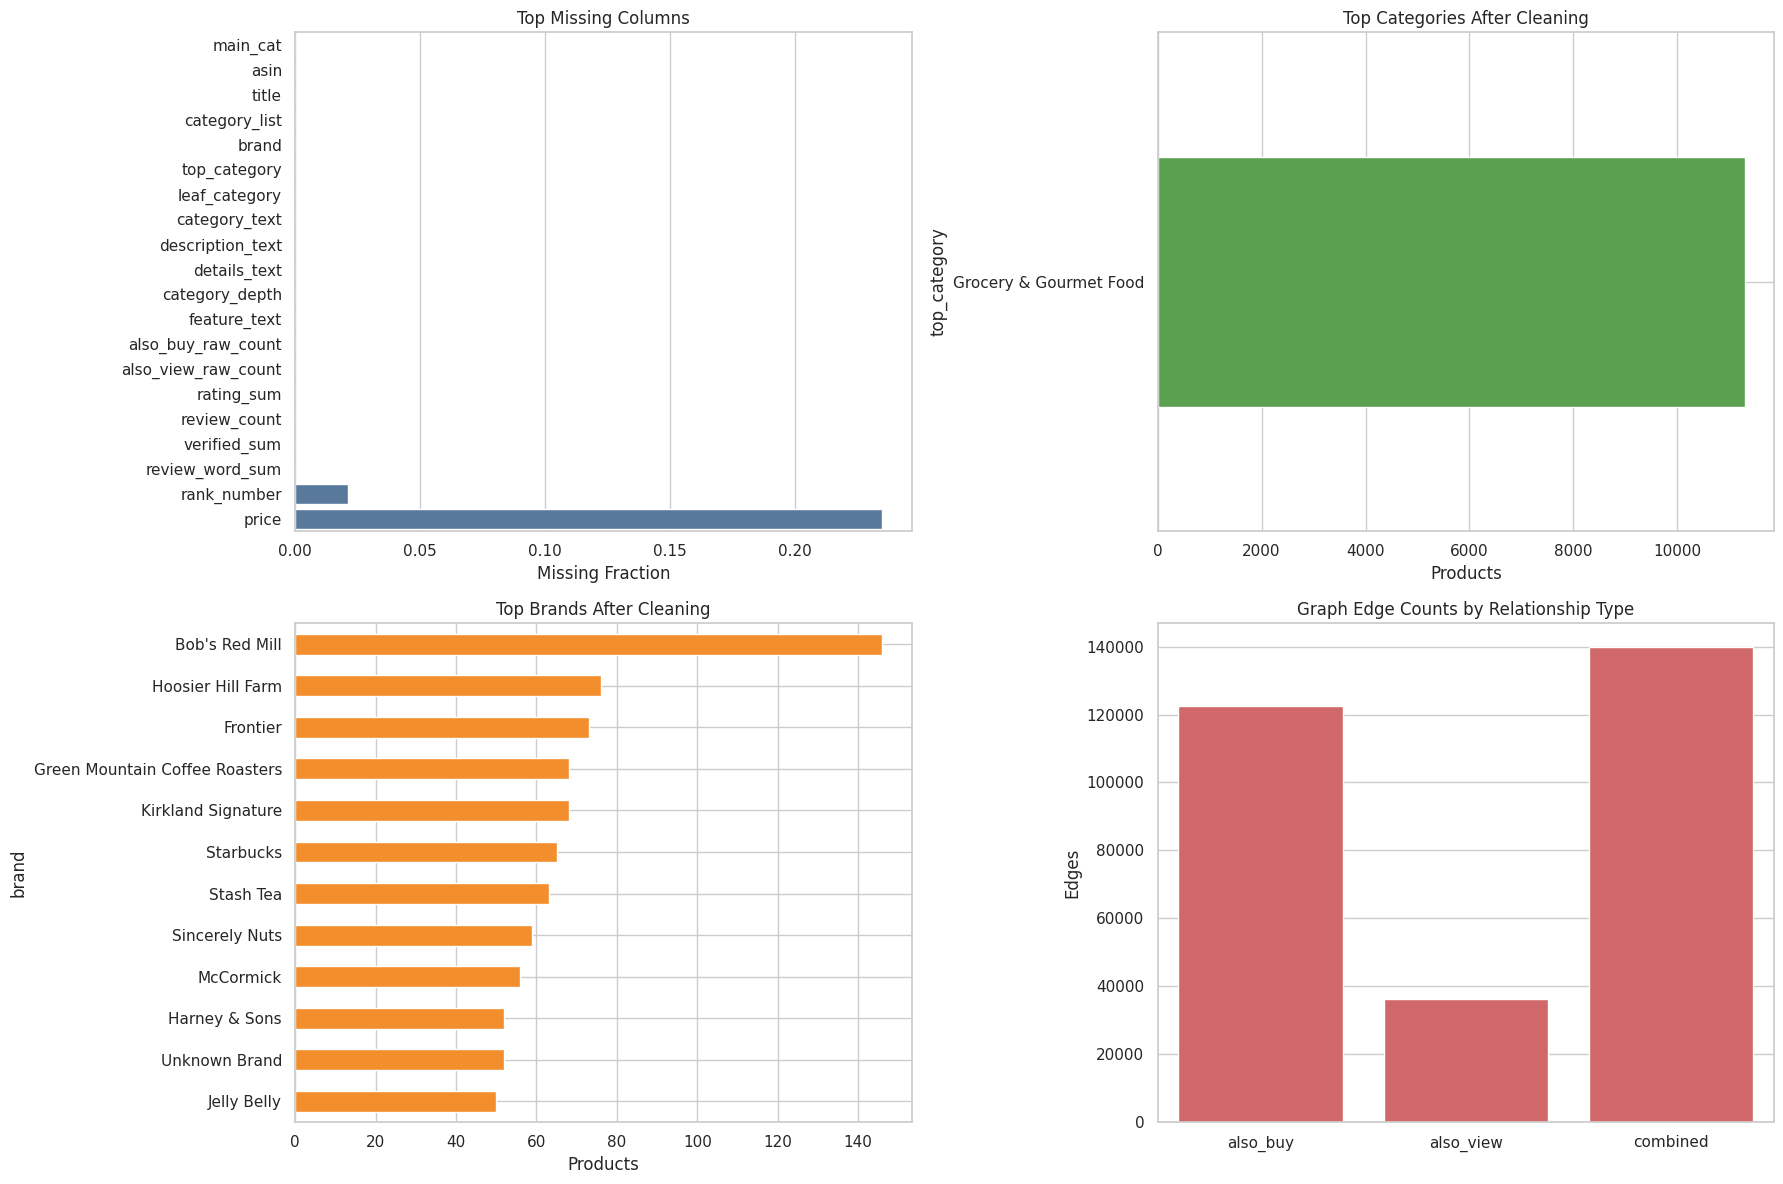

#### Top categories

,top_category,product_count
0,Grocery & Gourmet Food,11295


#### Top brands

,brand,product_count
0,Bob's Red Mill,146
1,Hoosier Hill Farm,76
2,Frontier,73
3,Kirkland Signature,68
4,Green Mountain Coffee Roasters,68
5,Starbucks,65
6,Stash Tea,63
7,Sincerely Nuts,59
8,McCormick,56
9,Unknown Brand,52


#### Edge type summary

,edge_type,edge_count
0,also_buy,122614
1,also_view,36271
2,combined,139855


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

missing_plot_df = missingness.head(20).sort_values("missing_fraction")
sns.barplot(data=missing_plot_df, x="missing_fraction", y="column", ax=axes[0, 0], color="#4c78a8")
axes[0, 0].set_title("Top Missing Columns")
axes[0, 0].set_xlabel("Missing Fraction")
axes[0, 0].set_ylabel("")

top_categories_plot = product_df["top_category"].fillna("Unknown").value_counts().head(12).sort_values()
top_categories_plot.plot(kind="barh", ax=axes[0, 1], color="#59a14f")
axes[0, 1].set_title("Top Categories After Cleaning")
axes[0, 1].set_xlabel("Products")

top_brands_plot = product_df["brand"].fillna("Unknown Brand").value_counts().head(12).sort_values()
top_brands_plot.plot(kind="barh", ax=axes[1, 0], color="#f28e2b")
axes[1, 0].set_title("Top Brands After Cleaning")
axes[1, 0].set_xlabel("Products")

edge_type_df = pd.DataFrame(
    {
        "edge_type": ["also_buy", "also_view", "combined"],
        "edge_count": [len(also_buy_edges), len(also_view_edges), len(all_graph_pairs)],
    }
)
sns.barplot(data=edge_type_df, x="edge_type", y="edge_count", ax=axes[1, 1], color="#e15759")
axes[1, 1].set_title("Graph Edge Counts by Relationship Type")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Edges")

plt.tight_layout()
plt.show()

display(Markdown("#### Top categories"))
display(product_df["top_category"].fillna("Unknown").value_counts().head(15).rename_axis("top_category").reset_index(name="product_count"))
display(Markdown("#### Top brands"))
display(product_df["brand"].fillna("Unknown Brand").value_counts().head(15).rename_axis("brand").reset_index(name="product_count"))
display(Markdown("#### Edge type summary"))
display(edge_type_df)


### Numeric Feature Exploration

In this block, I summarize the main numeric features so I can understand their scale and how they relate to each other.


#### Numeric summary before model preprocessing

,count,mean,std,min,25%,50%,75%,90%,max
review_count,11295.0,267.865870,467.091347,72.000000,96.000000,142.000000,256.000000,495.600000,1.152600e+04
avg_rating,11295.0,4.334547,0.381815,1.272727,4.165217,4.415929,4.600908,4.728682,5.000000e+00
verified_ratio,11295.0,0.890780,0.105807,0.000000,0.864078,0.923442,0.956140,0.974359,1.000000e+00
avg_review_length,11295.0,31.701651,12.021768,7.627907,23.441904,29.394444,37.213082,46.948124,1.361354e+02
price,8642.0,21.115246,20.481523,0.010000,11.112500,17.080000,26.625000,37.950000,9.990000e+02
rank_number,11056.0,80389.671038,117486.176668,4.000000,13154.500000,37887.500000,111168.000000,204331.000000,3.573503e+06
category_depth,11295.0,4.044887,0.766313,2.000000,4.000000,4.000000,5.000000,5.000000,1.000000e+01
description_length,11295.0,130.073484,123.717267,0.000000,52.000000,99.000000,170.000000,274.000000,1.453000e+03
graph_degree,11295.0,24.764055,31.540822,1.000000,9.000000,17.000000,30.000000,48.000000,5.430000e+02


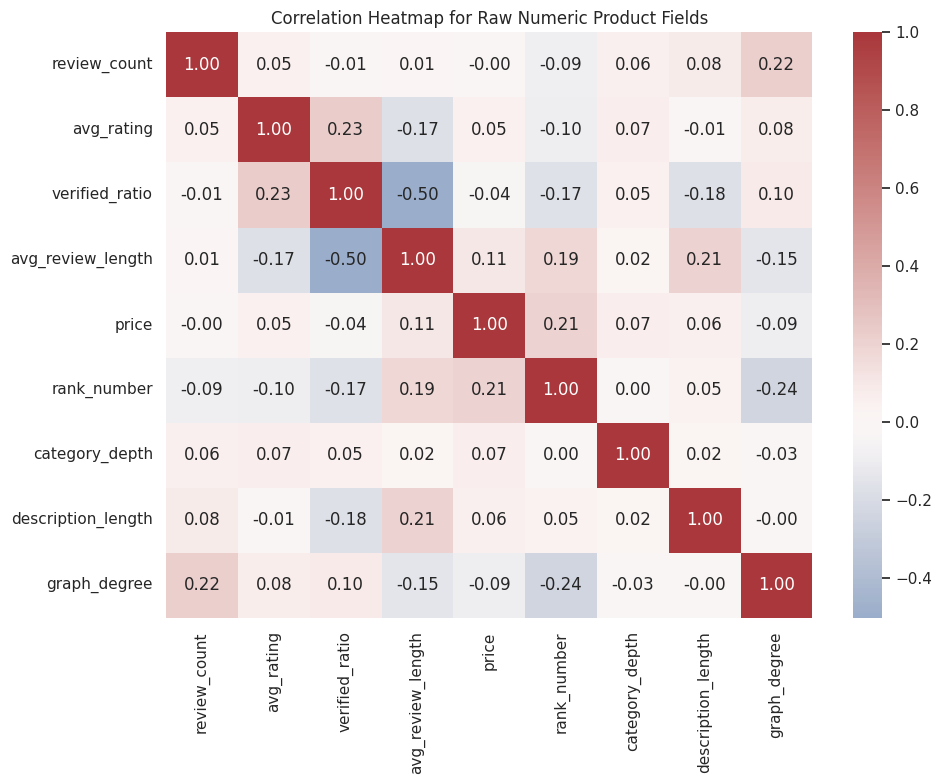

#### Example high-review products

,asin,title,brand,top_category,price,rank_number,review_count,avg_rating,graph_degree
0,B00BUKL666,"KIND Bars, Dark Chocolate Nuts &amp; Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,13.67,18.0,11526,4.516311,15
1,B00542YXFW,"Davidson's Tea Bulk, Anise Seed, 16-Ounce Bag",Davidson's Tea,Grocery & Gourmet Food,15.00,100853.0,9083,4.222944,26
2,B008QMX2SG,"Kind Bars, Madagascar Vanilla Almond, Gluten Free, Low Sugar, 1.4oz",KIND,Grocery & Gourmet Food,14.79,2949.0,8903,4.524093,20
3,B00D3M2QP4,"KIND Bars, Dark Chocolate Chili Almond, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,15.53,4575.0,8880,4.523649,18
4,B000YN2GVY,"Bragg Organic Unfiltered Apple Cider Vinegar, Raw, 16 Ounce - 1 Pack",Bragg,Grocery & Gourmet Food,6.98,4521.0,7400,4.512432,26
5,B000X3TPHS,"YumEarth Organic Lollipops, Assorted Flavors, 50 Lollipops",YumEarth,Grocery & Gourmet Food,NaN,11923.0,7310,4.720793,80
6,B01E5XTW24,"Green Mountain Coffee, Breakfast Blend Decaf, Single-Serve Keurig K-Cup Pods, Light Roast, 96-Count (4 Boxes of 24 Pods)",Green Mountain Coffee Roasters,Grocery & Gourmet Food,41.58,6517.0,7001,4.566633,23
7,B000F4DKAI,"Twinings of London English Afternoon Black Tea Bags, 20 Count (Pack of 6)",Twinings,Grocery & Gourmet Food,23.70,19796.0,6862,4.580880,21
8,B0001LO3FG,"Twinings of London Pure Camomile Herbal Tea Bags, 20 Count",Twinings,Grocery & Gourmet Food,NaN,142261.0,6858,4.580636,10
9,B000EVMNMI,"Haribo Gummi Candy, Happy-Cola, 5-Pound Bag",Haribo,Grocery & Gourmet Food,16.90,6571.0,6323,4.415942,45


#### Example sparse-graph products

,asin,title,brand,top_category,price,rank_number,review_count,avg_rating,graph_degree
100,B003Z6ZGZK,"Starbucks VIA Ready Brew Coffee, Italian, 3-Count Packets (Pack of 6)",Starbucks,Grocery & Gourmet Food,NaN,331874.0,2249,4.509560,1
144,B00XTVD9JG,Total Tea Gentle Detox Tea. Herbal Cleanse Tea Supplement for Health with Senna - Detox Cleanse for Weight Loss to get Skinny &amp; Fit ...,Total Tea,Grocery & Gourmet Food,17.99,797.0,1922,4.528616,1
237,B000V1AWBK,"Kitchens Of India Recipe Paste, Vegetable Biryani, 3.5 Ounce (Pack of 6)",Kitchens Of India,Grocery & Gourmet Food,NaN,306276.0,1419,4.581395,1
375,B00ESDZIRA,Crispy Green 100% Freeze-Dried Fruits,Crispy Green,Grocery & Gourmet Food,NaN,NaN,1075,3.868837,1
405,B001OI3RS4,"Celestial Seasonings Herb Tea Tension Tamer, 20-count (Pack of6)",Celestial Seasonings,Grocery & Gourmet Food,25.71,510437.0,1023,4.676442,1
532,B001EO617M,"Ambrosia Pure Honey From Colorado's Western Slope, 23-Ounce Bottles (Pack of 4)",Madhava,Grocery & Gourmet Food,NaN,299616.0,853,4.616647,1
662,B006WH61MQ,"Green Mountain Coffee Nantucket Blend,Medium Roast K-Cup Portion Pack for Keurig Brewers 72-Count",Green Mountain Coffee Roasters,Grocery & Gourmet Food,47.88,350920.0,738,4.517615,1
802,B005VOOOR0,"Nature Valley Chewy Granola Bar, Protein, Peanut Butter Dark Chocolate, 5 Bars - 1.4 oz (Pack of 4)",Nature Valley,Grocery & Gourmet Food,24.99,59862.0,647,4.462133,1
866,B006G7Z5WE,"Popchips Potato Chips, Sea Salt, 6.25 Ounce, (Pack of 6)",popchips,Grocery & Gourmet Food,NaN,313887.0,604,4.327815,1
1007,B00XK4JLGW,"nutpods Unsweetened Dairy-free Creamer, 4-pack (Original, Discontinued Listing)",Unknown Brand,Grocery & Gourmet Food,NaN,155366.0,538,4.293680,1


In [10]:
numeric_eda_columns = [
    "review_count",
    "avg_rating",
    "verified_ratio",
    "avg_review_length",
    "price",
    "rank_number",
    "category_depth",
    "description_length",
    "graph_degree",
]

numeric_summary_df = product_df[numeric_eda_columns].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).T
display(Markdown("#### Numeric summary before model preprocessing"))
display(numeric_summary_df)

corr_df = product_df[numeric_eda_columns].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap for Raw Numeric Product Fields")
plt.tight_layout()
plt.show()

example_columns = [
    "asin",
    "title",
    "brand",
    "top_category",
    "price",
    "rank_number",
    "review_count",
    "avg_rating",
    "graph_degree",
]
display(Markdown("#### Example high-review products"))
display(product_df.sort_values("review_count", ascending=False)[example_columns].head(10))
display(Markdown("#### Example sparse-graph products"))
display(product_df.sort_values(["graph_degree", "review_count"], ascending=[True, False])[example_columns].head(10))


### Distribution Plots

In this block, I plot the main feature distributions so I can see skew, spread, and concentration in the cleaned dataset.


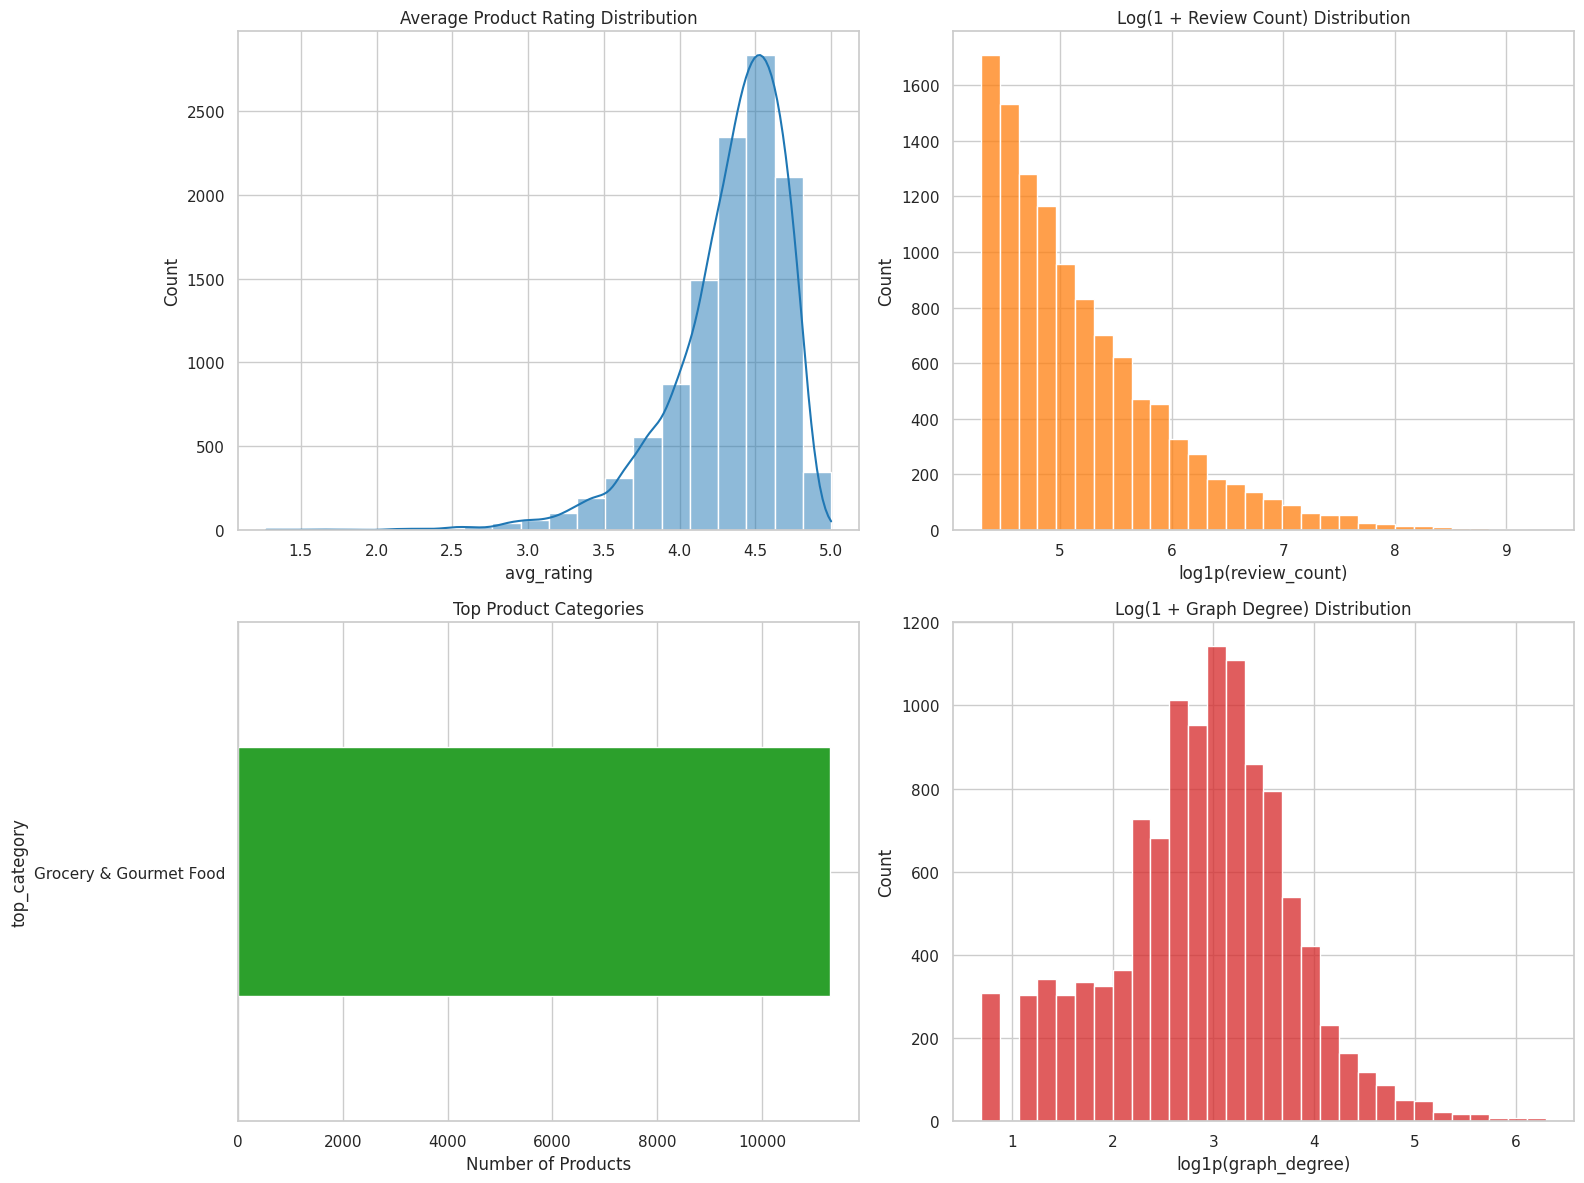

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(product_df["avg_rating"], bins=20, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Average Product Rating Distribution")

sns.histplot(np.log1p(product_df["review_count"]), bins=30, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].set_title("Log(1 + Review Count) Distribution")
axes[0, 1].set_xlabel("log1p(review_count)")

top_categories = product_df["top_category"].fillna("Unknown").value_counts().head(12).sort_values()
top_categories.plot(kind="barh", ax=axes[1, 0], color="#2ca02c")
axes[1, 0].set_title("Top Product Categories")
axes[1, 0].set_xlabel("Number of Products")

sns.histplot(np.log1p(product_df["graph_degree"]), bins=30, ax=axes[1, 1], color="#d62728")
axes[1, 1].set_title("Log(1 + Graph Degree) Distribution")
axes[1, 1].set_xlabel("log1p(graph_degree)")

plt.tight_layout()
plt.show()


### Temporal Coverage

In this block, I visualize the review timeline so I can understand the time span covered by the data.


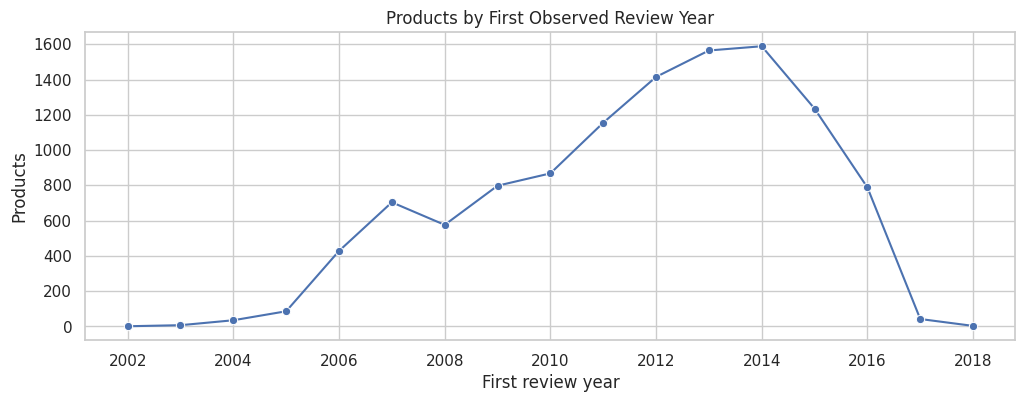

,title,brand,top_category,review_count,avg_rating,graph_degree
0,"KIND Bars, Dark Chocolate Nuts &amp; Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,11526,4.516311,15
1,"Davidson's Tea Bulk, Anise Seed, 16-Ounce Bag",Davidson's Tea,Grocery & Gourmet Food,9083,4.222944,26
2,"Kind Bars, Madagascar Vanilla Almond, Gluten Free, Low Sugar, 1.4oz",KIND,Grocery & Gourmet Food,8903,4.524093,20
3,"KIND Bars, Dark Chocolate Chili Almond, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,8880,4.523649,18
4,"Bragg Organic Unfiltered Apple Cider Vinegar, Raw, 16 Ounce - 1 Pack",Bragg,Grocery & Gourmet Food,7400,4.512432,26
5,"YumEarth Organic Lollipops, Assorted Flavors, 50 Lollipops",YumEarth,Grocery & Gourmet Food,7310,4.720793,80
6,"Green Mountain Coffee, Breakfast Blend Decaf, Single-Serve Keurig K-Cup Pods, Light Roast, 96-Count (4 Boxes of 24 Pods)",Green Mountain Coffee Roasters,Grocery & Gourmet Food,7001,4.566633,23
7,"Twinings of London English Afternoon Black Tea Bags, 20 Count (Pack of 6)",Twinings,Grocery & Gourmet Food,6862,4.580880,21
8,"Twinings of London Pure Camomile Herbal Tea Bags, 20 Count",Twinings,Grocery & Gourmet Food,6858,4.580636,10
9,"Haribo Gummi Candy, Happy-Cola, 5-Pound Bag",Haribo,Grocery & Gourmet Food,6323,4.415942,45


In [12]:
temporal_summary = (
    product_df["first_review_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="num_products")
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=temporal_summary, x="year", y="num_products", marker="o")
plt.title("Products by First Observed Review Year")
plt.xlabel("First review year")
plt.ylabel("Products")
plt.show()

product_df[["title", "brand", "top_category", "review_count", "avg_rating", "graph_degree"]].head(10)


## Train, Validation, and Test Split

In the next block, I create train, validation, and test edges so I can evaluate the recommender on held-out product links.


### Leakage-Safe Edge Split

In this block, I split the product graph carefully so the evaluation targets do not leak into the support graph.


,split,count
0,train_positive_edges,85829
1,val_positive_edges,18392
2,test_positive_edges,18393
3,strict_also_view_edges_used,30665
4,message_passing_edges,103070
5,raw_also_buy_also_view_overlap,19030
6,raw_test_edges_also_in_also_view,2765
7,strict_test_edges_also_in_also_view,0


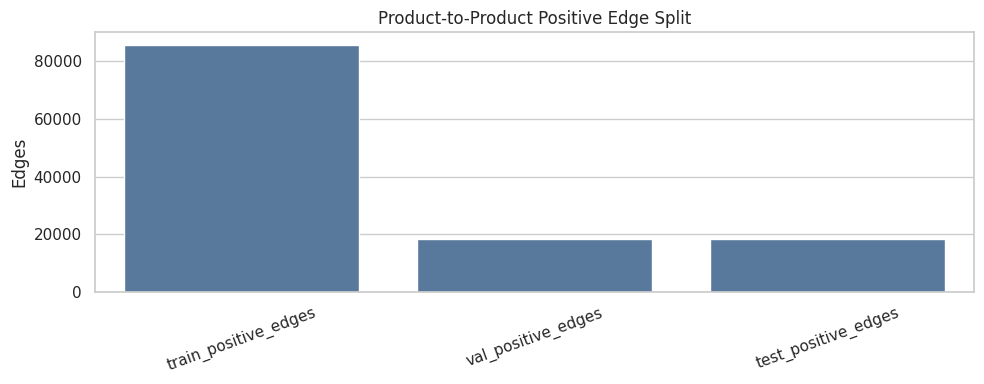

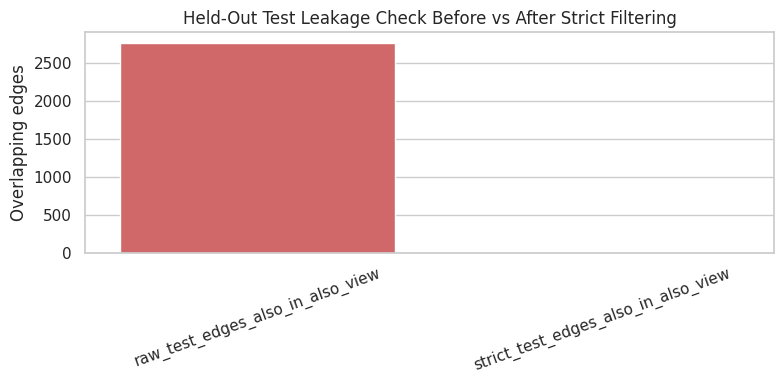

Raw held-out also_buy edges that appear in also_view: 2,765 / 18,393 (15.03%)
After strict overlap removal, held-out also_buy edges still visible in also_view: 0 / 18,393 (0.00%)


In [13]:
if len(also_buy_edges) < 100:
    raise ValueError("Too few also_buy edges for a meaningful link prediction split.")

# I split only also_buy edges because those are the product-to-product targets I want to predict.
train_edges, temp_edges = train_test_split(
    also_buy_edges,
    test_size=(VAL_EDGE_RATIO + TEST_EDGE_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_edges, test_edges = train_test_split(
    temp_edges,
    test_size=TEST_EDGE_RATIO / (VAL_EDGE_RATIO + TEST_EDGE_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True,
)

# I remove any also_view edge that duplicates a held-out also_buy target so the support graph stays leakage-safe.
heldout_buy_edge_set = {
    tuple(map(int, pair))
    for pair in np.vstack([val_edges, test_edges]).tolist()
}
strict_also_view_edges = np.array(
    [
        pair
        for pair in also_view_edges.tolist()
        if tuple(map(int, pair)) not in heldout_buy_edge_set
    ],
    dtype=np.int32,
)
# The support graph uses train also_buy edges plus the filtered also_view edges for message passing.
if len(strict_also_view_edges) > 0:
    support_graph_pairs = deduplicate_pairs(np.vstack([train_edges, strict_also_view_edges]))
else:
    support_graph_pairs = train_edges.copy()

also_buy_edge_set = {tuple(map(int, pair)) for pair in also_buy_edges.tolist()}
also_view_edge_set = {tuple(map(int, pair)) for pair in also_view_edges.tolist()}
strict_also_view_edge_set = {tuple(map(int, pair)) for pair in strict_also_view_edges.tolist()}
overlap_edge_count = len(also_buy_edge_set & also_view_edge_set)
test_overlap_count = sum(
    1 for pair in map(tuple, test_edges.tolist()) if pair in also_view_edge_set
)
strict_test_overlap_count = sum(
    1 for pair in map(tuple, test_edges.tolist()) if pair in strict_also_view_edge_set
)

# I summarize the split and the filtered support graph so I can verify the setup before training.
split_summary = pd.DataFrame(
    {
        "split": [
            "train_positive_edges",
            "val_positive_edges",
            "test_positive_edges",
            "strict_also_view_edges_used",
            "message_passing_edges",
            "raw_also_buy_also_view_overlap",
            "raw_test_edges_also_in_also_view",
            "strict_test_edges_also_in_also_view",
        ],
        "count": [
            len(train_edges),
            len(val_edges),
            len(test_edges),
            len(strict_also_view_edges),
            len(support_graph_pairs),
            overlap_edge_count,
            test_overlap_count,
            strict_test_overlap_count,
        ],
    }
)
display(split_summary)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=split_summary.loc[
        split_summary["split"].isin(["train_positive_edges", "val_positive_edges", "test_positive_edges"])
    ],
    x="split",
    y="count",
    color="#4c78a8",
)
plt.title("Product-to-Product Positive Edge Split")
plt.xlabel("")
plt.ylabel("Edges")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# I compare raw vs filtered overlap to confirm that held-out test edges are no longer visible in also_view.
leakage_check_df = split_summary.loc[
    split_summary["split"].isin(
        [
            "raw_test_edges_also_in_also_view",
            "strict_test_edges_also_in_also_view",
        ]
    )
].copy()
plt.figure(figsize=(8, 4))
sns.barplot(data=leakage_check_df, x="split", y="count", color="#e15759")
plt.title("Held-Out Test Leakage Check Before vs After Strict Filtering")
plt.xlabel("")
plt.ylabel("Overlapping edges")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print(
    "Raw held-out also_buy edges that appear in also_view:",
    f"{test_overlap_count:,} / {len(test_edges):,} ({test_overlap_count / len(test_edges):.2%})",
)
print(
    "After strict overlap removal, held-out also_buy edges still visible in also_view:",
    f"{strict_test_overlap_count:,} / {len(test_edges):,} ({strict_test_overlap_count / len(test_edges):.2%})",
)


## Feature Engineering and Preprocessing

In this block, I create text, numeric, missingness, and support-graph features so each product has a richer representation for ranking.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# I combine metadata into one text field so the text encoder sees a single product description.
product_df["metadata_blob"] = (
    product_df["title"].fillna("")
    + ". Brand: " + product_df["brand"].fillna("")
    + ". Category: " + product_df["category_text"].fillna("")
    + ". Description: " + product_df["description_text"].fillna("")
    + ". Features: " + product_df["feature_text"].fillna("")
).str.replace(r"\s+", " ", regex=True).str.strip()
# I keep review snippets separate so I can build a second text view from customer language.
product_df["review_text_blob"] = (
    "Review summary: " + product_df["review_snippets"].fillna("")
).str.replace(r"\s+", " ", regex=True).str.strip()

# I compute degree from the training support graph, not the full graph, so this feature stays leakage-safe.
support_graph_degree_for_features = np.zeros(num_nodes, dtype=np.float32)
for src, dst in map(tuple, support_graph_pairs):
    support_graph_degree_for_features[int(src)] += 1
    support_graph_degree_for_features[int(dst)] += 1

feature_df = product_df.copy()
feature_df["support_graph_degree"] = support_graph_degree_for_features

# I log-scale skewed numeric fields and keep missingness flags as explicit features.
feature_df["log_review_count"] = np.log1p(feature_df["review_count"])
feature_df["log_price"] = np.log1p(feature_df["price"].clip(lower=0))
feature_df["log_rank_number"] = np.log1p(feature_df["rank_number"].clip(lower=0))
feature_df["log_description_length"] = np.log1p(feature_df["description_length"].clip(lower=0).fillna(0))
feature_df["log_support_graph_degree"] = np.log1p(feature_df["support_graph_degree"].clip(lower=0).fillna(0))
feature_df["has_description"] = (feature_df["description_missing_flag"] == 0).astype(np.int8)
feature_df["has_feature_bullets"] = (feature_df["feature_missing_flag"] == 0).astype(np.int8)
feature_df["has_review_snippets"] = (feature_df["review_snippet_missing_flag"] == 0).astype(np.int8)

numeric_feature_columns = [
    "log_review_count",
    "avg_rating",
    "verified_ratio",
    "avg_review_length",
    "log_price",
    "log_rank_number",
    "category_depth",
    "log_description_length",
    "log_support_graph_degree",
    "brand_missing_flag",
    "category_missing_flag",
    "price_missing_flag",
    "rank_missing_flag",
    "description_missing_flag",
    "feature_missing_flag",
    "review_snippet_missing_flag",
    "has_description",
    "has_feature_bullets",
    "has_review_snippets",
]

# I keep a compact table of the engineered feature groups so the feature design is easy to inspect.
feature_selection_df = pd.DataFrame(
    [
        ("metadata_blob", "text", "title + brand + category + description + features", "main content signal and cold-start fallback"),
        ("review_text_blob", "text", "representative review snippets", "captures shopper language and use cases"),
        ("log_review_count", "numeric", "log1p(review_count)", "popularity / confidence signal"),
        ("avg_rating", "numeric", "mean product rating", "quality signal"),
        ("verified_ratio", "numeric", "verified reviews / total reviews", "review reliability signal"),
        ("avg_review_length", "numeric", "mean review word count", "review richness signal"),
        ("log_price", "numeric", "log1p(price), median-imputed", "price similarity and purchase context"),
        ("log_rank_number", "numeric", "log1p(sales rank proxy), median-imputed", "market popularity proxy"),
        ("category_depth", "numeric", "number of category levels", "metadata specificity"),
        ("log_description_length", "numeric", "log1p(description word count)", "metadata richness"),
        ("log_support_graph_degree", "numeric", "log1p(training support graph degree)", "leakage-safe graph popularity/connectivity"),
        ("missing flags", "binary", "brand/category/price/rank/text missing indicators", "preserve information from missingness"),
    ],
    columns=["feature_group", "type", "transformation", "why_selected"],
)
display(Markdown("### Selected features and engineering rationale"))
display(feature_selection_df)

numeric_missing_before_imputation = (
    feature_df[numeric_feature_columns]
    .isna()
    .sum()
    .rename("missing_before_imputation")
    .reset_index()
    .rename(columns={"index": "numeric_feature"})
)
numeric_missing_before_imputation["missing_fraction"] = (
    numeric_missing_before_imputation["missing_before_imputation"] / max(len(feature_df), 1)
)
display(Markdown("### Numeric missing values handled by median imputation"))
display(numeric_missing_before_imputation.loc[numeric_missing_before_imputation["missing_before_imputation"] > 0])

text_preview_columns = [
    "asin",
    "title",
    "metadata_blob",
    "review_text_blob",
    "brand_missing_flag",
    "price_missing_flag",
    "rank_missing_flag",
]
display(Markdown("### Example engineered text fields and missing-value flags"))
display(feature_df[text_preview_columns].head(5))

missing_flag_summary = (
    feature_df[
        [
            "brand_missing_flag",
            "category_missing_flag",
            "price_missing_flag",
            "rank_missing_flag",
            "description_missing_flag",
            "feature_missing_flag",
            "review_snippet_missing_flag",
        ]
    ]
    .sum()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "missing_flag"})
)
missing_flag_summary["fraction_of_products"] = missing_flag_summary["count"] / max(len(feature_df), 1)
display(Markdown("### Missing-value indicator features"))
display(missing_flag_summary)

# I try sentence-transformer embeddings first and fall back to TF-IDF + SVD if needed.
def build_text_embedding_matrix(texts):
    try:
        from sentence_transformers import SentenceTransformer

        sentence_model = SentenceTransformer(TEXT_MODEL_NAME, device=DEVICE)
        embeddings = sentence_model.encode(
            texts,
            batch_size=TEXT_BATCH_SIZE,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        method = "sentence-transformer"
    except Exception as exc:
        print(f"SentenceTransformer failed ({exc}). Falling back to TF-IDF + TruncatedSVD.")
        vectorizer = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            stop_words="english",
        )
        tfidf = vectorizer.fit_transform(texts)
        n_components = min(TEXT_EMBED_DIM_FALLBACK, max(2, tfidf.shape[1] - 1))
        svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
        embeddings = svd.fit_transform(tfidf)
        embeddings = normalize(embeddings)
        method = "tfidf_svd"
    return embeddings.astype(np.float32), method

# I build separate embeddings for metadata text and review text, then combine them later.
metadata_embedding_matrix, metadata_text_method = build_text_embedding_matrix(
    feature_df["metadata_blob"].tolist()
)
review_text_inputs = feature_df["review_text_blob"].where(
    feature_df["review_text_blob"].str.len() > 20,
    feature_df["title"],
)
review_text_embedding_matrix, review_text_method = build_text_embedding_matrix(
    review_text_inputs.tolist()
)

print("Metadata embedding method:", metadata_text_method)
print("Metadata embedding shape:", metadata_embedding_matrix.shape)
print("Review-text embedding method:", review_text_method)
print("Review-text embedding shape:", review_text_embedding_matrix.shape)

numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()
# I median-impute the numeric features and standardize them before concatenating them with text embeddings.
numeric_matrix = numeric_imputer.fit_transform(feature_df[numeric_feature_columns])
numeric_matrix = numeric_scaler.fit_transform(numeric_matrix).astype(np.float32)
numeric_scaled_df = pd.DataFrame(numeric_matrix, columns=numeric_feature_columns, index=feature_df.index)
numeric_imputation_values_df = pd.DataFrame(
    {
        "numeric_feature": numeric_feature_columns,
        "median_imputation_value": numeric_imputer.statistics_,
    }
)
preprocessing_check_df = pd.DataFrame(
    {
        "check": [
            "Numeric feature columns",
            "Numeric matrix missing values after imputation",
            "Numeric matrix shape",
        ],
        "value": [
            len(numeric_feature_columns),
            int(np.isnan(numeric_matrix).sum()),
            str(numeric_matrix.shape),
        ],
    }
)
display(Markdown("### Numeric preprocessing check"))
display(preprocessing_check_df)
display(numeric_imputation_values_df)

numeric_scaled_preview_df = pd.DataFrame(
    numeric_scaled_df.head(5).to_numpy(dtype=np.float32),
    columns=numeric_scaled_df.columns,
    index=feature_df["asin"].head(5),
)
display(Markdown("### First five rows after median imputation and standard scaling"))
display(numeric_scaled_preview_df)

metadata_embeddings = normalize(metadata_embedding_matrix)
review_text_embeddings = normalize(review_text_embedding_matrix)
content_embeddings = normalize(
    0.60 * metadata_embeddings + 0.40 * review_text_embeddings
).astype(np.float32)

full_feature_matrix = np.hstack(
    [metadata_embedding_matrix, review_text_embedding_matrix, numeric_matrix]
).astype(np.float32)
x_tensor = torch.tensor(full_feature_matrix, dtype=torch.float32, device=DEVICE)

display(feature_df[["asin", "title", "review_count", "avg_rating", "graph_degree", "support_graph_degree"]].head(5))
print("Full feature matrix shape:", full_feature_matrix.shape)
embedding_summary_df = pd.DataFrame(
    {
        "matrix": ["metadata_embeddings", "review_text_embeddings", "numeric_matrix", "full_feature_matrix"],
        "shape": [
            str(metadata_embedding_matrix.shape),
            str(review_text_embedding_matrix.shape),
            str(numeric_matrix.shape),
            str(full_feature_matrix.shape),
        ],
        "purpose": [
            "product title/brand/category/description/features",
            "customer review language",
            "scaled numeric metadata, missingness flags, and support-graph degree",
            "node feature matrix used by the GAT model",
        ],
    }
)
display(Markdown("### Final model input matrices"))
display(embedding_summary_df)


### Selected features and engineering rationale

,feature_group,type,transformation,why_selected
0,metadata_blob,text,title + brand + category + description + features,main content signal and cold-start fallback
1,review_text_blob,text,representative review snippets,captures shopper language and use cases
2,log_review_count,numeric,log1p(review_count),popularity / confidence signal
3,avg_rating,numeric,mean product rating,quality signal
4,verified_ratio,numeric,verified reviews / total reviews,review reliability signal
5,avg_review_length,numeric,mean review word count,review richness signal
6,log_price,numeric,"log1p(price), median-imputed",price similarity and purchase context
7,log_rank_number,numeric,"log1p(sales rank proxy), median-imputed",market popularity proxy
8,category_depth,numeric,number of category levels,metadata specificity
9,log_description_length,numeric,log1p(description word count),metadata richness


### Numeric missing values handled by median imputation

,numeric_feature,missing_before_imputation,missing_fraction
4,log_price,2653,0.234883
5,log_rank_number,239,0.021160


### Example engineered text fields and missing-value flags

...

,log_review_count,avg_rating,verified_ratio,avg_review_length,log_price,log_rank_number,category_depth,log_description_length,log_support_graph_degree,brand_missing_flag,category_missing_flag,price_missing_flag,rank_missing_flag,description_missing_flag,feature_missing_flag,review_snippet_missing_flag,has_description,has_feature_bullets,has_review_snippets
asin,,,,,,,,,,,,,,,,,,,
B00BUKL666,5.478557,0.476074,0.158974,-0.688521,-0.410226,-4.865712,-0.058578,0.790868,-0.020252,-0.068008,0.0,-0.554066,-0.147028,-0.334398,0.433096,0.0,0.334398,-0.433096,0.0
B00542YXFW,5.166719,-0.292308,0.624392,1.031029,-0.245897,0.720695,1.246429,-0.338501,0.535035,-0.068008,0.0,-0.554066,-0.147028,-0.334398,0.433096,0.0,0.334398,-0.433096,0.0
B008QMX2SG,5.140516,0.496457,0.179820,-0.744992,-0.270914,-1.579699,-0.058578,0.692188,0.356547,-0.068008,0.0,-0.554066,-0.147028,-0.334398,0.433096,0.0,0.334398,-0.433096,0.0
B00D3M2QP4,5.137129,0.495293,0.179740,-0.743810,-0.184190,-1.293754,-0.058578,0.431075,0.145441,-0.068008,0.0,-0.554066,-0.147028,-0.334398,0.433096,0.0,0.334398,-0.433096,0.0
B000YN2GVY,4.898451,0.465915,-0.035475,0.380169,-1.563137,-1.301486,1.246429,0.823906,0.478542,-0.068008,0.0,-0.554066,-0.147028,-0.334398,0.433096,0.0,0.334398,-0.433096,0.0


,asin,title,review_count,avg_rating,graph_degree,support_graph_degree
0,B00BUKL666,"KIND Bars, Dark Chocolate Nuts &amp; Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",11526,4.516311,15,12.0
1,B00542YXFW,"Davidson's Tea Bulk, Anise Seed, 16-Ounce Bag",9083,4.222944,26,20.0
2,B008QMX2SG,"Kind Bars, Madagascar Vanilla Almond, Gluten Free, Low Sugar, 1.4oz",8903,4.524093,20,17.0
3,B00D3M2QP4,"KIND Bars, Dark Chocolate Chili Almond, Gluten Free, 1.4 Ounce Bars, 12 Count",8880,4.523649,18,14.0
4,B000YN2GVY,"Bragg Organic Unfiltered Apple Cider Vinegar, Raw, 16 Ounce - 1 Pack",7400,4.512432,26,19.0


Full feature matrix shape: (11295, 787)


### Final model input matrices

,matrix,shape,purpose
0,metadata_embeddings,"(11295, 384)",product title/brand/category/description/features
1,review_text_embeddings,"(11295, 384)",customer review language
2,numeric_matrix,"(11295, 19)","scaled numeric metadata, missingness flags, and support-graph degree"
3,full_feature_matrix,"(11295, 787)",node feature matrix used by the GAT model


## Review-Aware Collaborative Features

In this block, I turn positive co-review behavior into item-item signals so I can add collaborative information beyond metadata.


Loading cached review collaborative artifacts...


,metric,value
0,Eligible review-CF users,440472.0
1,Review-CF scored pairs,1820243.0
2,Products with review-CF neighbors,11295.0
3,Median positive-user count per product,56.0


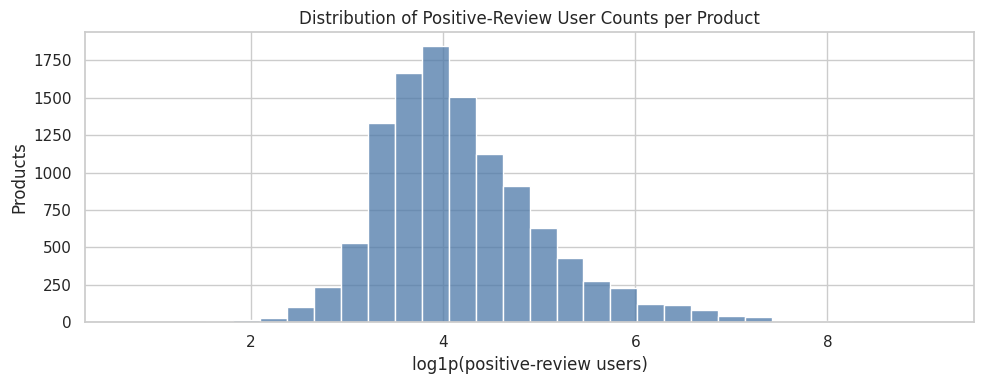

### Products with the strongest review-CF interaction support

,node_id,asin,title,brand,top_category,review_count,positive_review_users
0,0,B00BUKL666,"KIND Bars, Dark Chocolate Nuts &amp; Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,11526,9014
2,2,B008QMX2SG,"Kind Bars, Madagascar Vanilla Almond, Gluten Free, Low Sugar, 1.4oz",KIND,Grocery & Gourmet Food,8903,7318
3,3,B00D3M2QP4,"KIND Bars, Dark Chocolate Chili Almond, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,8880,7297
7,7,B000F4DKAI,"Twinings of London English Afternoon Black Tea Bags, 20 Count (Pack of 6)",Twinings,Grocery & Gourmet Food,6862,5741
8,8,B0001LO3FG,"Twinings of London Pure Camomile Herbal Tea Bags, 20 Count",Twinings,Grocery & Gourmet Food,6858,5738
20,20,B00XA8XWGS,"Twinings of London Christmas Black Tea Bags, 20 Count",Twinings,Grocery & Gourmet Food,4870,3942
27,27,B00R7PWK7W,"KIND Bars, Caramel Almond and Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,4617,3705
6,6,B01E5XTW24,"Green Mountain Coffee, Breakfast Blend Decaf, Single-Serve Keurig K-Cup Pods, Light Roast, 96-Count (4 Boxes of 24 Pods)",Green Mountain Coffee Roasters,Grocery & Gourmet Food,7001,3455
36,36,B00KSN9TME,"KIND Bars, Dark Chocolate Nuts &amp; Sea Salt, Gluten Free, 1.4 Ounce Bars, 12 Count",KIND,Grocery & Gourmet Food,3847,3327
40,40,B000HDK0DC,"YumEarth Organic Lollipops, Assorted Flavors, 5 Pound Bag",YumEarth,Grocery & Gourmet Food,3705,3311


In [15]:
# This function converts positive co-review behavior into item-item collaborative signals.
def build_review_cf_artifacts():
    if REVIEW_CF_CACHE.exists() and not FORCE_REBUILD_CACHE:
        print("Loading cached review collaborative artifacts...")
        return pd.read_pickle(REVIEW_CF_CACHE)

    asin_to_node = dict(zip(product_df["asin"], product_df["node_id"]))
    selected_asins = set(asin_to_node)

    # First, I count positive reviewer activity so I can filter out very small or very large user histories.
    print("Review CF pass 1/2: counting positive reviewer interactions...")
    user_positive_counts = defaultdict(int)
    for obj in tqdm(stream_json_lines(REVIEW_PATH)):
        asin = obj.get("asin")
        if asin not in selected_asins:
            continue
        if float(obj.get("overall", 0) or 0) < POSITIVE_RATING_THRESHOLD:
            continue
        reviewer_id = obj.get("reviewerID")
        if not reviewer_id:
            continue
        user_positive_counts[reviewer_id] += 1

    eligible_users = {
        reviewer_id
        for reviewer_id, count in user_positive_counts.items()
        if REVIEW_CF_MIN_USER_ITEMS <= count <= REVIEW_CF_MAX_USER_ITEMS
    }
    print(f"Eligible review-CF users: {len(eligible_users):,}")

    # Then, I rebuild eligible user histories and turn co-reviewed products into item-item pairs.
    print("Review CF pass 2/2: collecting item histories for eligible users...")
    user_items = defaultdict(set)
    for obj in tqdm(stream_json_lines(REVIEW_PATH)):
        asin = obj.get("asin")
        if asin not in selected_asins:
            continue
        if float(obj.get("overall", 0) or 0) < POSITIVE_RATING_THRESHOLD:
            continue
        reviewer_id = obj.get("reviewerID")
        if reviewer_id not in eligible_users:
            continue
        user_items[reviewer_id].add(asin_to_node[asin])

    # I score each pair with overlap-based similarity so the strongest co-review neighbors rise to the top.
    item_positive_user_count = np.zeros(num_nodes, dtype=np.int32)
    pair_counts = defaultdict(int)

    for items in tqdm(user_items.values(), desc="Building review co-occurrence pairs"):
        items = sorted(items)
        if len(items) < REVIEW_CF_MIN_USER_ITEMS:
            continue
        for node_id in items:
            item_positive_user_count[node_id] += 1
        for left_idx, left_node in enumerate(items):
            for right_node in items[left_idx + 1:]:
                pair_counts[(left_node, right_node)] += 1

    review_cf_neighbors = {node_id: [] for node_id in range(num_nodes)}
    for (left_node, right_node), co_count in tqdm(pair_counts.items(), desc="Scoring review-CF pairs"):
        left_count = max(int(item_positive_user_count[left_node]), 1)
        right_count = max(int(item_positive_user_count[right_node]), 1)
        cosine_score = co_count / math.sqrt(left_count * right_count)
        jaccard_score = co_count / max(left_count + right_count - co_count, 1)
        combined_score = 0.70 * cosine_score + 0.30 * jaccard_score
        review_cf_neighbors[left_node].append((right_node, float(combined_score), int(co_count)))
        review_cf_neighbors[right_node].append((left_node, float(combined_score), int(co_count)))

    for node_id in review_cf_neighbors:
        review_cf_neighbors[node_id].sort(key=lambda row: (row[1], row[2]), reverse=True)
        review_cf_neighbors[node_id] = review_cf_neighbors[node_id][:REVIEW_CF_TOP_NEIGHBORS]

    # I save the precomputed review-CF artifacts so the rest of the notebook can reuse them quickly.
    artifacts = {
        "eligible_user_count": len(eligible_users),
        "item_positive_user_count": item_positive_user_count,
        "review_cf_neighbors": review_cf_neighbors,
        "pair_count": len(pair_counts),
    }
    pd.to_pickle(artifacts, REVIEW_CF_CACHE)
    print("Saved review collaborative artifacts to:", REVIEW_CF_CACHE)
    return artifacts

review_cf_artifacts = build_review_cf_artifacts()
review_cf_neighbors = review_cf_artifacts["review_cf_neighbors"]
review_positive_user_count = review_cf_artifacts["item_positive_user_count"]
review_positive_user_count_scaled = (
    np.log1p(review_positive_user_count) /
    np.log1p(max(float(review_positive_user_count.max()), 1.0))
).astype(np.float32)

review_cf_summary = pd.DataFrame(
    {
        "metric": [
            "Eligible review-CF users",
            "Review-CF scored pairs",
            "Products with review-CF neighbors",
            "Median positive-user count per product",
        ],
        "value": [
            review_cf_artifacts["eligible_user_count"],
            review_cf_artifacts["pair_count"],
            sum(1 for node_id in range(num_nodes) if len(review_cf_neighbors[node_id]) > 0),
            float(np.median(review_positive_user_count)),
        ],
    }
)
display(review_cf_summary)

plt.figure(figsize=(10, 4))
sns.histplot(np.log1p(review_positive_user_count), bins=30, color="#4c78a8")
plt.title("Distribution of Positive-Review User Counts per Product")
plt.xlabel("log1p(positive-review users)")
plt.ylabel("Products")
plt.tight_layout()
plt.show()

top_review_cf_products = product_df.loc[
    np.argsort(review_positive_user_count)[::-1][:10],
    ["node_id", "asin", "title", "brand", "top_category", "review_count"],
].copy()
top_review_cf_products["positive_review_users"] = review_positive_user_count[
    top_review_cf_products["node_id"].to_numpy(dtype=np.int32)
]
display(Markdown("### Products with the strongest review-CF interaction support"))
display(top_review_cf_products)


## Baseline Models and GNN Development

In the next blocks, I prepare graph-based baselines and neural models so I can compare different ways of learning product similarity.


### Graph feature summary

,metric,value
0,Support graph nodes,11295.000000
1,Support graph edges,103070.000000
2,Train buy edges,85829.000000
3,Adjacency SVD dimensions,64.000000
4,Mean support degree,18.250553
5,Median support degree,13.000000
6,Max support degree,385.000000


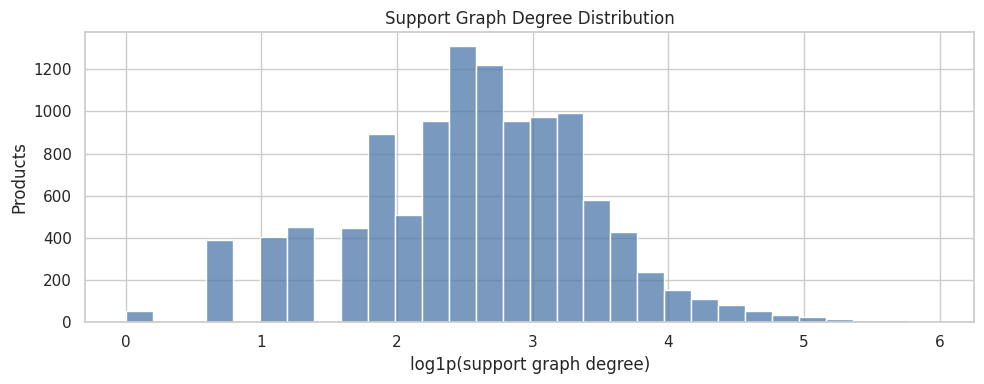

In [16]:
# I build both the support graph and the train-only also_buy graph because later features use both views.
support_graph = nx.Graph()
support_graph.add_nodes_from(range(num_nodes))
support_graph.add_edges_from(map(tuple, support_graph_pairs))

train_buy_graph = nx.Graph()
train_buy_graph.add_nodes_from(range(num_nodes))
train_buy_graph.add_edges_from(map(tuple, train_edges))

# These degree-based features become simple structural baselines and popularity signals.
support_degree = np.array([support_graph.degree(node_id) for node_id in range(num_nodes)], dtype=np.float32)
train_buy_degree = np.array([train_buy_graph.degree(node_id) for node_id in range(num_nodes)], dtype=np.float32)
popularity_order = np.argsort(-train_buy_degree)

# I convert the graphs into sparse matrices so I can run matrix-factorization and similarity baselines efficiently.
support_adjacency_matrix = nx.to_scipy_sparse_array(
    support_graph,
    nodelist=range(num_nodes),
    format="csr",
    dtype=np.float32,
)

buy_adjacency_matrix = nx.to_scipy_sparse_array(
    train_buy_graph,
    nodelist=range(num_nodes),
    format="csr",
    dtype=np.float32,
)

svd_components = min(64, max(2, num_nodes - 1))
svd_model = TruncatedSVD(n_components=svd_components, random_state=RANDOM_STATE)
adjacency_svd_embeddings = svd_model.fit_transform(support_adjacency_matrix)
adjacency_svd_embeddings = normalize(adjacency_svd_embeddings)

brand_codes = pd.factorize(product_df["brand"].fillna("Unknown Brand"))[0].astype(np.int32)
top_category_codes = pd.factorize(product_df["top_category"].fillna("Unknown Category"))[0].astype(np.int32)
leaf_category_codes = pd.factorize(product_df["leaf_category"].fillna("Unknown Leaf"))[0].astype(np.int32)
price_feature_array = numeric_scaled_df["log_price"].to_numpy(dtype=np.float32)
support_degree_scaled = (np.log1p(support_degree) / np.log1p(max(float(support_degree.max()), 1.0))).astype(np.float32)
buy_degree_scaled = (np.log1p(train_buy_degree) / np.log1p(max(float(train_buy_degree.max()), 1.0))).astype(np.float32)

graph_feature_summary = pd.DataFrame(
    {
        "metric": [
            "Support graph nodes",
            "Support graph edges",
            "Train buy edges",
            "Adjacency SVD dimensions",
            "Mean support degree",
            "Median support degree",
            "Max support degree",
        ],
        "value": [
            support_graph.number_of_nodes(),
            support_graph.number_of_edges(),
            train_buy_graph.number_of_edges(),
            adjacency_svd_embeddings.shape[1],
            float(np.mean(support_degree)),
            float(np.median(support_degree)),
            float(np.max(support_degree)),
        ],
    }
)
display(Markdown("### Graph feature summary"))
display(graph_feature_summary)

plt.figure(figsize=(10, 4))
sns.histplot(np.log1p(support_degree), bins=30, color="#4c78a8")
plt.title("Support Graph Degree Distribution")
plt.xlabel("log1p(support graph degree)")
plt.ylabel("Products")
plt.tight_layout()
plt.show()


### GNN Model Definitions

In this block, I define GraphSAGE, LightGCN, and GAT so I can compare different graph encoders on the same recommendation task.


In [17]:
from torch_geometric.nn import GATv2Conv, LGConv, SAGEConv
from torch_geometric.utils import negative_sampling, to_undirected

# I convert undirected edge lists into PyG edge_index format for the graph models.
def make_edge_index(pairs):
    if len(pairs) == 0:
        return torch.empty((2, 0), dtype=torch.long, device=DEVICE)
    edge_index = torch.tensor(pairs.T, dtype=torch.long, device=DEVICE)
    return to_undirected(edge_index, num_nodes=num_nodes)

# The support graph is the message-passing graph, while all_positive_edge_index protects negative sampling from known graph positives.
support_edge_index = make_edge_index(support_graph_pairs)
available_graph_pairs = deduplicate_pairs(np.vstack([also_buy_edges, strict_also_view_edges])) if len(strict_also_view_edges) > 0 else also_buy_edges.copy()
all_positive_edge_index = make_edge_index(available_graph_pairs)

train_edge_tensor = torch.tensor(train_edges, dtype=torch.long, device=DEVICE)
val_edge_tensor = torch.tensor(val_edges, dtype=torch.long, device=DEVICE)
test_edge_tensor = torch.tensor(test_edges, dtype=torch.long, device=DEVICE)

# GraphSAGE learns node embeddings from local neighborhood aggregation.
class GraphSAGERecommender(nn.Module):
    def __init__(self, num_nodes, hidden_channels=64, out_channels=64, dropout=0.20):
        super().__init__()
        self.dropout = dropout
        self.node_embedding = nn.Embedding(num_nodes, hidden_channels)
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def encode(self, edge_index):
        x = self.node_embedding.weight
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.normalize(x, p=2, dim=1)

    def decode(self, z, edge_pairs):
        return (z[edge_pairs[:, 0]] * z[edge_pairs[:, 1]]).sum(dim=1)

# GAT uses attention over the input feature matrix, so it can blend graph structure with rich product features.
class GATRecommender(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=64, heads=4, dropout=0.20):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.normalize(x, p=2, dim=1)

    def decode(self, z, edge_pairs):
        return (z[edge_pairs[:, 0]] * z[edge_pairs[:, 1]]).sum(dim=1)

# LightGCN propagates only node embeddings, which makes it a lightweight graph-only baseline.
class LightGCNRecommender(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.node_embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

    def encode(self, edge_index):
        x = self.node_embedding.weight
        xs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            xs.append(x)
        x = torch.stack(xs, dim=0).mean(dim=0)
        return F.normalize(x, p=2, dim=1)

    def decode(self, z, edge_pairs):
        return (z[edge_pairs[:, 0]] * z[edge_pairs[:, 1]]).sum(dim=1)


### Training and Ranking Utilities

In this block, I define negative sampling, training, and ranking utilities so all of the models can be trained and evaluated consistently.


In [18]:
# I separate also_view-only pairs so I can use them as hard negatives for the also_buy task.
all_buy_edge_set = {tuple(map(int, pair)) for pair in also_buy_edges.tolist()}
also_view_only_pairs = np.array(
    [pair for pair in strict_also_view_edges.tolist() if tuple(map(int, pair)) not in all_buy_edge_set],
    dtype=np.int32,
)

# I mix hard negatives with random non-edges so training sees both confusing and easy negatives.
def sample_negative_edges(num_samples, hard_negative_ratio=TRAIN_HARD_NEGATIVE_RATIO):
    num_hard = min(int(num_samples * hard_negative_ratio), len(also_view_only_pairs))

    if num_hard > 0:
        hard_indices = np.random.choice(len(also_view_only_pairs), size=num_hard, replace=False)
        hard_negative_edges = torch.tensor(
            also_view_only_pairs[hard_indices],
            dtype=torch.long,
            device=DEVICE,
        )
    else:
        hard_negative_edges = torch.empty((0, 2), dtype=torch.long, device=DEVICE)

    num_random = max(num_samples - num_hard, 0)
    if num_random > 0:
        random_neg_edge_index = negative_sampling(
            edge_index=all_positive_edge_index,
            num_nodes=num_nodes,
            num_neg_samples=num_random,
            method="sparse",
        )
        random_negative_edges = random_neg_edge_index.t().contiguous()
    else:
        random_negative_edges = torch.empty((0, 2), dtype=torch.long, device=DEVICE)

    if len(hard_negative_edges) == 0:
        return random_negative_edges
    if len(random_negative_edges) == 0:
        return hard_negative_edges
    return torch.cat([hard_negative_edges, random_negative_edges], dim=0)

# I evaluate link prediction with AUC and Average Precision on held-out positive and negative edges.
def edge_classification_metrics(model, z, positive_edges, negative_edges):
    pos_scores = model.decode(z, positive_edges).detach().cpu().numpy()
    neg_scores = model.decode(z, negative_edges).detach().cpu().numpy()
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_score = 1 / (1 + np.exp(-np.concatenate([pos_scores, neg_scores])))
    return {
        "auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
    }

# I combine pointwise classification loss with a pairwise ranking term so the embeddings learn both separation and ordering.
def link_prediction_loss(model, z, positive_edges, negative_edges):
    pos_scores = model.decode(z, positive_edges)
    neg_scores = model.decode(z, negative_edges)
    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat(
        [torch.ones_like(pos_scores), torch.zeros_like(neg_scores)]
    )
    bce_loss = F.binary_cross_entropy_with_logits(scores, labels)
    paired_neg_scores = neg_scores[: len(pos_scores)]
    ranking_loss = -torch.log(torch.sigmoid(pos_scores - paired_neg_scores) + 1e-8).mean()
    return 0.5 * bce_loss + 0.5 * ranking_loss

# This training loop uses fresh negatives, monitors validation quality, and restores the best checkpoint with early stopping.
def train_model(model, model_name, x_features=None):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_val_auc = -np.inf
    epochs_without_improvement = 0
    history = []

    fixed_val_negatives = sample_negative_edges(len(val_edge_tensor))

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()

        if x_features is None:
            z = model.encode(support_edge_index)
        else:
            z = model.encode(x_features, support_edge_index)

        negative_edges = sample_negative_edges(len(train_edge_tensor))
        loss = link_prediction_loss(model, z, train_edge_tensor, negative_edges)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            if x_features is None:
                z_val = model.encode(support_edge_index)
            else:
                z_val = model.encode(x_features, support_edge_index)
            val_metrics = edge_classification_metrics(model, z_val, val_edge_tensor, fixed_val_negatives)

        history.append(
            {
                "epoch": epoch,
                "train_loss": float(loss.item()),
                "val_auc": val_metrics["auc"],
                "val_average_precision": val_metrics["average_precision"],
            }
        )

        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 5 == 0 or epoch == NUM_EPOCHS:
            print(
                f"{model_name} | epoch={epoch:02d} | "
                f"loss={loss.item():.4f} | val_auc={val_metrics['auc']:.4f} | "
                f"val_ap={val_metrics['average_precision']:.4f}"
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"{model_name} early stopping triggered at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        if x_features is None:
            final_embeddings = model.encode(support_edge_index).detach().cpu().numpy()
        else:
            final_embeddings = model.encode(x_features, support_edge_index).detach().cpu().numpy()

    history_df = pd.DataFrame(history)
    return normalize(final_embeddings), history_df

# I rank products by embedding similarity after removing the query item and any training neighbors.
def make_embedding_ranker(embeddings, seen_lookup):
    embeddings = normalize(embeddings)

    def recommend(query_idx, k):
        query_vector = embeddings[query_idx]
        scores = embeddings @ query_vector
        scores = scores.astype(np.float32, copy=True)
        scores[query_idx] = -np.inf
        seen_items = list(seen_lookup.get(query_idx, set()))
        if seen_items:
            scores[seen_items] = -np.inf
        k = min(k, len(scores) - 1)
        topk = np.argpartition(scores, -k)[-k:]
        topk = topk[np.argsort(scores[topk])[::-1]]
        return topk

    return recommend

def make_popularity_ranker(popularity_order, seen_lookup):
    def recommend(query_idx, k):
        recs = []
        seen_items = seen_lookup.get(query_idx, set())
        for item in popularity_order:
            if item == query_idx or item in seen_items:
                continue
            recs.append(int(item))
            if len(recs) == k:
                break
        return np.array(recs, dtype=np.int32)

    return recommend

# This baseline reuses filtered also_view neighbors directly and backs off to popularity when needed.
def make_direct_also_view_ranker(primary_embeddings, secondary_embeddings, also_view_lookup, seen_lookup, popularity_order):
    primary_embeddings = normalize(primary_embeddings)
    secondary_embeddings = normalize(secondary_embeddings)

    def recommend(query_idx, k):
        candidates = [node for node in also_view_lookup.get(query_idx, set()) if node not in seen_lookup.get(query_idx, set()) and node != query_idx]
        if candidates:
            candidates = np.array(candidates, dtype=np.int32)
            scores = (
                0.60 * (primary_embeddings[candidates] @ primary_embeddings[query_idx])
                + 0.25 * (secondary_embeddings[candidates] @ secondary_embeddings[query_idx])
                + 0.15 * buy_degree_scaled[candidates]
            )
            ordered = candidates[np.argsort(scores)[::-1]]
            recs = ordered[:k].tolist()
        else:
            recs = []

        if len(recs) < k:
            for item in popularity_order:
                if item == query_idx or item in seen_lookup.get(query_idx, set()) or item in recs:
                    continue
                recs.append(int(item))
                if len(recs) == k:
                    break
        return np.array(recs, dtype=np.int32)

    return recommend

# I evaluate each ranker with HitRate, Recall, NDCG, and MRR at several cutoff values.
def ranking_metrics_for_queries(ground_truth, ranker, topk_values, query_subset=None):
    if query_subset is None:
        query_subset = sorted([node for node, targets in ground_truth.items() if len(targets) > 0])
    topk_values = sorted(set(int(k) for k in topk_values))
    max_k = max(topk_values)
    metric_store = {
        k: {
            "hit_rates": [],
            "recalls": [],
            "ndcgs": [],
            "mrrs": [],
        }
        for k in topk_values
    }

    for query_idx in query_subset:
        relevant = ground_truth.get(query_idx, set())
        if not relevant:
            continue
        recs = [int(node_id) for node_id in ranker(query_idx, max_k)]

        for k in topk_values:
            top_recs = recs[:k]
            hits = [1 if rec in relevant else 0 for rec in top_recs]
            hit_count = sum(hits)
            metric_store[k]["hit_rates"].append(float(hit_count > 0))
            metric_store[k]["recalls"].append(hit_count / len(relevant))

            dcg = sum(hit / math.log2(rank + 2) for rank, hit in enumerate(hits))
            ideal_hits = min(len(relevant), k)
            idcg = sum(1 / math.log2(rank + 2) for rank in range(ideal_hits))
            metric_store[k]["ndcgs"].append(dcg / idcg if idcg > 0 else 0.0)

            reciprocal_rank = 0.0
            for rank, rec in enumerate(top_recs):
                if rec in relevant:
                    reciprocal_rank = 1.0 / (rank + 1)
                    break
            metric_store[k]["mrrs"].append(reciprocal_rank)

    metrics = {}
    for k in topk_values:
        metrics[f"HitRate@{k}"] = np.mean(metric_store[k]["hit_rates"]) if metric_store[k]["hit_rates"] else np.nan
        metrics[f"Recall@{k}"] = np.mean(metric_store[k]["recalls"]) if metric_store[k]["recalls"] else np.nan
        metrics[f"NDCG@{k}"] = np.mean(metric_store[k]["ndcgs"]) if metric_store[k]["ndcgs"] else np.nan
        metrics[f"MRR@{k}"] = np.mean(metric_store[k]["mrrs"]) if metric_store[k]["mrrs"] else np.nan
    return metrics


### GNN Training

In this block, I train the graph encoders on the support graph so I can use their embeddings for product ranking.


In [19]:
train_buy_lookup = build_neighbor_lookup(train_edges, num_nodes)
support_lookup = build_neighbor_lookup(support_graph_pairs, num_nodes)
also_view_lookup = build_neighbor_lookup(strict_also_view_edges, num_nodes)
val_ground_truth = build_neighbor_lookup(val_edges, num_nodes)
test_ground_truth = build_neighbor_lookup(test_edges, num_nodes)

graphsage_model = GraphSAGERecommender(
    num_nodes=num_nodes,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=HIDDEN_CHANNELS,
    dropout=DROPOUT,
).to(DEVICE)

lightgcn_model = LightGCNRecommender(
    num_nodes=num_nodes,
    embedding_dim=HIDDEN_CHANNELS,
    num_layers=3,
).to(DEVICE)

gat_model = GATRecommender(
    in_channels=x_tensor.shape[1],
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=HIDDEN_CHANNELS,
    heads=4,
    dropout=DROPOUT,
).to(DEVICE)

graphsage_embeddings, graphsage_history = train_model(graphsage_model, "GraphSAGE", x_features=None)
lightgcn_embeddings, lightgcn_history = train_model(lightgcn_model, "LightGCN", x_features=None)
gat_embeddings, gat_history = train_model(gat_model, "GAT", x_features=x_tensor)


GraphSAGE | epoch=01 | loss=0.6962 | val_auc=0.5485 | val_ap=0.5405
GraphSAGE | epoch=05 | loss=0.6891 | val_auc=0.5466 | val_ap=0.5407
GraphSAGE | epoch=10 | loss=0.6826 | val_auc=0.5630 | val_ap=0.5533
GraphSAGE | epoch=15 | loss=0.6771 | val_auc=0.5743 | val_ap=0.5608
GraphSAGE | epoch=20 | loss=0.6705 | val_auc=0.5788 | val_ap=0.5624
GraphSAGE | epoch=25 | loss=0.6637 | val_auc=0.5915 | val_ap=0.5714
GraphSAGE | epoch=30 | loss=0.6568 | val_auc=0.6064 | val_ap=0.5830
LightGCN | epoch=01 | loss=0.6650 | val_auc=0.4794 | val_ap=0.4657
LightGCN | epoch=05 | loss=0.6649 | val_auc=0.4794 | val_ap=0.4658
LightGCN | epoch=10 | loss=0.6648 | val_auc=0.4795 | val_ap=0.4658
LightGCN | epoch=15 | loss=0.6648 | val_auc=0.4796 | val_ap=0.4659
LightGCN | epoch=20 | loss=0.6649 | val_auc=0.4796 | val_ap=0.4659
LightGCN | epoch=25 | loss=0.6648 | val_auc=0.4797 | val_ap=0.4659
LightGCN | epoch=30 | loss=0.6648 | val_auc=0.4798 | val_ap=0.4660
GAT | epoch=01 | loss=0.6212 | val_auc=0.7772 | val_ap=

### Training Curves

In this block, I plot the training curves so I can see whether the models are learning and where they start to level off.


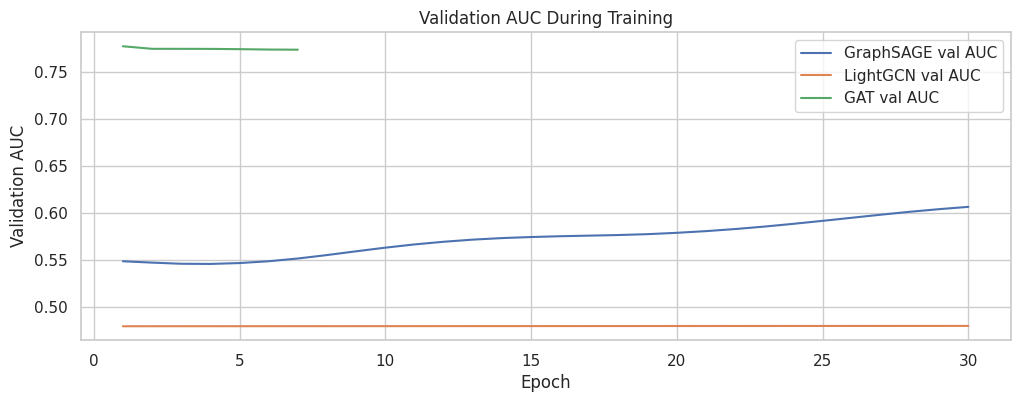

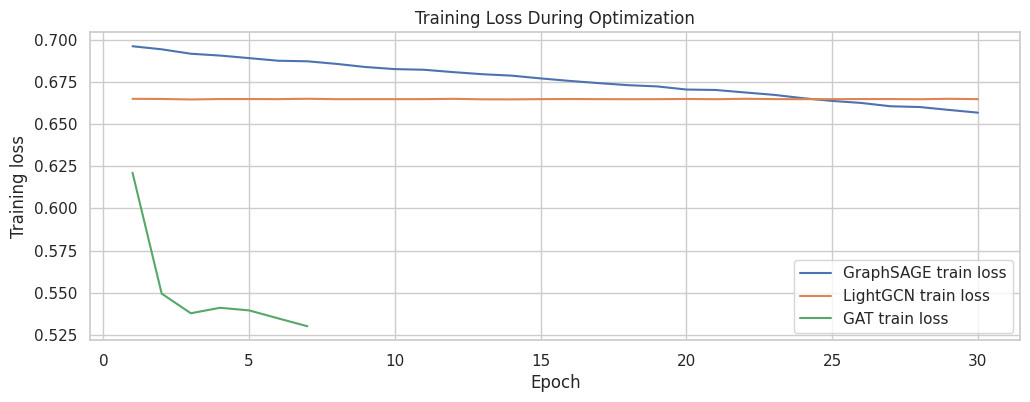

### GNN validation diagnostic summary

,model,best_val_auc,best_val_average_precision,epochs_run
2,GAT,0.777186,0.703038,7
0,GraphSAGE,0.606379,0.583024,30
1,LightGCN,0.479761,0.465975,30


**Interpretation note:** Treat LightGCN as a structural baseline. Only describe it as strong if the validation and test tables support that claim.

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(graphsage_history["epoch"], graphsage_history["val_auc"], label="GraphSAGE val AUC")
plt.plot(lightgcn_history["epoch"], lightgcn_history["val_auc"], label="LightGCN val AUC")
plt.plot(gat_history["epoch"], gat_history["val_auc"], label="GAT val AUC")
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC During Training")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(graphsage_history["epoch"], graphsage_history["train_loss"], label="GraphSAGE train loss")
plt.plot(lightgcn_history["epoch"], lightgcn_history["train_loss"], label="LightGCN train loss")
plt.plot(gat_history["epoch"], gat_history["train_loss"], label="GAT train loss")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss During Optimization")
plt.legend()
plt.show()

gnn_training_summary = pd.DataFrame(
    {
        "model": ["GraphSAGE", "LightGCN", "GAT"],
        "best_val_auc": [
            graphsage_history["val_auc"].max(),
            lightgcn_history["val_auc"].max(),
            gat_history["val_auc"].max(),
        ],
        "best_val_average_precision": [
            graphsage_history["val_average_precision"].max(),
            lightgcn_history["val_average_precision"].max(),
            gat_history["val_average_precision"].max(),
        ],
        "epochs_run": [
            len(graphsage_history),
            len(lightgcn_history),
            len(gat_history),
        ],
    }
).sort_values("best_val_auc", ascending=False)

display(Markdown("### GNN validation diagnostic summary"))
display(gnn_training_summary)
display(Markdown(
    "**Interpretation note:** Treat LightGCN as a structural baseline. "
    "Only describe it as strong if the validation and test tables support that claim."
))


### Leakage Diagnostics

In this block, I measure held-out overlap diagnostics so I can confirm that the auxiliary graph is filtered correctly.


In [21]:
overlap_diagnostics = pd.DataFrame(
    {
        "metric": [
            "Held-out also_buy edges",
            "Raw held-out edges also present in also_view",
            "Raw overlap rate",
            "Strict held-out edges still present in also_view",
            "Strict overlap rate",
        ],
        "value": [
            len(test_edges),
            sum(1 for pair in map(tuple, test_edges.tolist()) if pair in also_view_edge_set),
            sum(1 for pair in map(tuple, test_edges.tolist()) if pair in also_view_edge_set) / len(test_edges),
            sum(1 for pair in map(tuple, test_edges.tolist()) if pair in strict_also_view_edge_set),
            sum(1 for pair in map(tuple, test_edges.tolist()) if pair in strict_also_view_edge_set) / len(test_edges),
        ],
    }
)
display(overlap_diagnostics)

# I convert review-CF neighbors into a dictionary so pair lookups are fast later.
review_cf_lookup = {
    node_id: {neighbor_id: (score, co_count) for neighbor_id, score, co_count in neighbors}
    for node_id, neighbors in review_cf_neighbors.items()
}

# I tokenize titles and brands so I can build lexical similarity features.
title_token_sets = [
    {
        token
        for token in re.findall(r"[a-z0-9]+", normalize_text(title_text))
        if len(token) > 2
    }
    for title_text in product_df["title"].fillna("").tolist()
]
brand_token_sets = [
    {
        token
        for token in re.findall(r"[a-z0-9]+", normalize_text(brand_text))
        if len(token) > 2
    }
    for brand_text in product_df["brand"].fillna("").tolist()
]

# I keep generic packaging words separate so they do not dominate duplicate detection.
generic_variant_tokens = {
    "pack", "packs", "count", "ounce", "ounces", "oz", "pound", "pounds", "lb", "lbs",
    "gram", "grams", "kg", "ml", "liter", "liters", "fluid", "mini", "size", "family",
    "variety", "assorted", "bars", "bar", "cookies", "cookie", "chips", "cracker", "crackers",
    "snack", "snacks", "bites", "box", "boxes", "bag", "bags", "can", "cans", "bottle",
    "bottles", "jar", "jars", "original", "organic", "natural", "gluten", "free", "classic",
    "style", "made", "with", "whole", "grain", "roasted", "toasted",
}

# I also separate common flavor words so the remaining title tokens capture the product family better.
flavor_tokens = {
    "vanilla", "chocolate", "dark", "milk", "strawberry", "raspberry", "blueberry", "berry",
    "peanut", "butter", "caramel", "cinnamon", "hazelnut", "mocha", "almond", "honey",
    "maple", "apple", "banana", "mint", "orange", "lemon", "lime", "coconut", "mango",
    "pineapple", "grape", "cherry", "ginger", "turmeric", "bbq", "cheddar", "nacho",
    "salt", "sea", "spicy", "jalapeno", "mozzarella", "coffee", "espresso", "pumpkin",
    "pecan", "walnut", "cashew", "cranberry",
}

# These filtered title tokens help me detect near-duplicate variants more reliably.
family_token_sets = [
    {
        token
        for token in title_token_sets[node_id]
        if token not in brand_token_sets[node_id]
        and token not in generic_variant_tokens
        and token not in flavor_tokens
    }
    for node_id in range(num_nodes)
]

brand_present_mask = product_df["brand"].fillna("").str.strip().str.len().gt(0).to_numpy(dtype=bool)
leaf_category_present_mask = product_df["leaf_category"].fillna("").str.strip().str.len().gt(0).to_numpy(dtype=bool)
avg_rating_array = product_df["avg_rating"].fillna(product_df["avg_rating"].median()).to_numpy(dtype=np.float32)

# I retrieve the top candidates from a score vector after masking the query item
# and any training neighbors that should not be recommended again.
def top_indices_from_scores(scores, query_idx, seen_lookup, top_n):
    scores = scores.astype(np.float32, copy=True)
    scores[query_idx] = -np.inf
    seen_items = list(seen_lookup.get(query_idx, set()))
    if seen_items:
        scores[seen_items] = -np.inf
    top_n = min(max(top_n, 1), len(scores) - 1)
    idx = np.argpartition(scores, -top_n)[-top_n:]
    return idx[np.argsort(scores[idx])[::-1]]

# I use all known graph positives here so random negatives do not accidentally include
# also_buy positives or filtered also_view support edges.
all_graph_pair_set = {tuple(map(int, pair)) for pair in available_graph_pairs.tolist()}

# This sampler creates random non-edge pairs for reranker negatives.
def sample_random_non_edges(num_samples):
    if num_samples <= 0:
        return np.empty((0, 2), dtype=np.int32)
    sampled = set()
    while len(sampled) < num_samples:
        src = np.random.randint(0, num_nodes)
        dst = np.random.randint(0, num_nodes)
        if src == dst:
            continue
        pair = tuple(sorted((int(src), int(dst))))
        if pair in all_graph_pair_set:
            continue
        sampled.add(pair)
    return np.array(sorted(sampled), dtype=np.int32)

# I use Jaccard overlap on title tokens as a lightweight lexical similarity feature.
def title_jaccard_score(left_node, right_node):
    left_tokens = title_token_sets[int(left_node)]
    right_tokens = title_token_sets[int(right_node)]
    if not left_tokens or not right_tokens:
        return 0.0
    union_size = len(left_tokens | right_tokens)
    if union_size == 0:
        return 0.0
    return len(left_tokens & right_tokens) / union_size

def pair_title_jaccard_scores(left_nodes, right_nodes):
    return np.array(
        [title_jaccard_score(left_node, right_node) for left_node, right_node in zip(left_nodes, right_nodes)],
        dtype=np.float32,
    )

# I compute a second overlap score using family-level title tokens after removing
# brand, flavor, and packaging words.
def family_jaccard_score(left_node, right_node):
    left_tokens = family_token_sets[int(left_node)]
    right_tokens = family_token_sets[int(right_node)]
    if not left_tokens or not right_tokens:
        return 0.0
    union_size = len(left_tokens | right_tokens)
    if union_size == 0:
        return 0.0
    return len(left_tokens & right_tokens) / union_size

# I flag likely near-duplicate products so the retriever can penalize them
# and the serving step can diversify them.
def are_variant_duplicates(left_node, right_node):
    left_node = int(left_node)
    right_node = int(right_node)
    same_brand = (
        brand_present_mask[left_node]
        and brand_present_mask[right_node]
        and int(brand_codes[left_node]) == int(brand_codes[right_node])
    )
    if not same_brand:
        return False
    same_leaf_category = (
        leaf_category_present_mask[left_node]
        and leaf_category_present_mask[right_node]
        and int(leaf_category_codes[left_node]) == int(leaf_category_codes[right_node])
    )
    if not same_leaf_category:
        return False
    title_overlap = title_jaccard_score(left_node, right_node)
    family_overlap = family_jaccard_score(left_node, right_node)
    return (title_overlap >= 0.58) or (family_overlap >= 0.72) or (title_overlap >= 0.46 and family_overlap >= 0.55)

# I rescale candidate scores locally inside each source before combining them.
def scale_local_scores(values):
    values = np.asarray(values, dtype=np.float32)
    if len(values) == 0:
        return values
    min_val = float(values.min())
    max_val = float(values.max())
    if max_val - min_val < 1e-8:
        return np.ones_like(values, dtype=np.float32)
    return (values - min_val) / (max_val - min_val)

# These are the default weights for the stage-1 multi-source retriever.
default_stage1_params = {
    "candidate_pool": HYBRID_STAGE1_CANDIDATE_POOL,
    "per_source": HYBRID_STAGE1_PER_SOURCE,
    "review_cf_scale": 1.00,
    "also_view_scale": 1.00,
    "graph_scale": 1.00,
    "content_scale": 1.00,
    "metadata_scale": 1.00,
    "review_text_scale": 1.00,
    "svd_scale": 1.00,
    "support_scale": 1.00,
    "multi_source_bonus": 0.04,
    "near_duplicate_penalty": 0.14,
    "same_brand_penalty": 0.06,
}

# This function builds one shared candidate pool by combining review-CF, also_view,
# graph embedding similarity, text similarity, SVD similarity, and graph expansion.
def build_hybrid_candidate_pool(query_idx, candidate_pool=HYBRID_STAGE1_CANDIDATE_POOL, per_source=HYBRID_STAGE1_PER_SOURCE, params=None):
    params = default_stage1_params if params is None else {**default_stage1_params, **params}
    candidate_pool = int(params.get("candidate_pool", candidate_pool))
    per_source = int(params.get("per_source", per_source))
    review_cf_scale = float(params.get("review_cf_scale", 1.0))
    also_view_scale = float(params.get("also_view_scale", 1.0))
    graph_scale = float(params.get("graph_scale", 1.0))
    content_scale = float(params.get("content_scale", 1.0))
    metadata_scale = float(params.get("metadata_scale", 1.0))
    review_text_scale = float(params.get("review_text_scale", 1.0))
    svd_scale = float(params.get("svd_scale", 1.0))
    support_scale = float(params.get("support_scale", 1.0))
    multi_source_bonus = float(params.get("multi_source_bonus", 0.04))
    near_duplicate_penalty = float(params.get("near_duplicate_penalty", 0.14))
    same_brand_penalty = float(params.get("same_brand_penalty", 0.06))
    seen_items = train_buy_lookup.get(query_idx, set())
    score_map = defaultdict(float)
    source_tracker = defaultdict(set)

    # This helper accumulates score contributions from multiple sources
    # while filtering out invalid or already-seen candidates.
    def register(candidate_id, contribution, source_name):
        candidate_id = int(candidate_id)
        if candidate_id == query_idx or candidate_id in seen_items:
            return
        if contribution <= 0:
            return
        score_map[candidate_id] += float(contribution)
        source_tracker[candidate_id].add(source_name)

    # Review-CF contributes collaborative signals from shared positive-review users.
    for rank, (neighbor_id, review_score, co_count) in enumerate(review_cf_neighbors.get(query_idx, [])[:per_source], 1):
        register(
            neighbor_id,
            review_cf_scale * (
                0.90 * float(review_score) + 0.03 * min(float(co_count), 10.0) + 0.06 / math.sqrt(rank)
            ),
            "review_cf",
        )

    # also_view contributes auxiliary graph candidates after leakage-safe filtering.
    ranked_also_view = sorted(
        also_view_lookup.get(query_idx, set()),
        key=lambda node_id: support_degree[node_id],
        reverse=True,
    )[:per_source]
    for rank, neighbor_id in enumerate(ranked_also_view, 1):
        register(neighbor_id, also_view_scale * (0.18 + 0.08 / math.sqrt(rank)), "also_view")

    # These sources contribute embedding-based similarity from graph, metadata, review text, and SVD spaces.
    source_score_specs = [
        ("gat", gat_embeddings @ gat_embeddings[query_idx], 0.36 * graph_scale),
        ("graphsage", graphsage_embeddings @ graphsage_embeddings[query_idx], 0.24 * graph_scale),
        ("lightgcn", lightgcn_embeddings @ lightgcn_embeddings[query_idx], 0.28 * graph_scale),
        ("metadata", metadata_embeddings @ metadata_embeddings[query_idx], 0.20 * metadata_scale),
        ("review_text", review_text_embeddings @ review_text_embeddings[query_idx], 0.18 * review_text_scale),
        ("content", content_embeddings @ content_embeddings[query_idx], 0.28 * content_scale),
        ("svd", adjacency_svd_embeddings @ adjacency_svd_embeddings[query_idx], 0.16 * svd_scale),
    ]
    for source_name, source_scores, source_weight in source_score_specs:
        candidate_ids = top_indices_from_scores(source_scores, query_idx, train_buy_lookup, per_source)
        if len(candidate_ids) == 0:
            continue
        scaled_scores = scale_local_scores(source_scores[candidate_ids])
        for rank, (candidate_id, scaled_score) in enumerate(zip(candidate_ids.tolist(), scaled_scores.tolist()), 1):
            register(
                candidate_id,
                source_weight * (0.80 * float(scaled_score) + 0.20 / math.sqrt(rank)),
                source_name,
            )

    # I also expand through one-hop and two-hop support-graph neighbors
    # to recover structurally related products that may not rank highly by embeddings alone.
    high_degree_support_neighbors = sorted(
        support_lookup.get(query_idx, set()),
        key=lambda node_id: support_degree[node_id],
        reverse=True,
    )[:TWO_HOP_EXPANSION]
    for rank, neighbor in enumerate(high_degree_support_neighbors, 1):
        register(neighbor, support_scale * (0.10 + 0.02 / math.sqrt(rank)), "support_one_hop")
        expanded_neighbors = sorted(
            support_lookup.get(neighbor, set()),
            key=lambda node_id: support_degree[node_id],
            reverse=True,
        )[:TWO_HOP_EXPANSION]
        for two_hop_rank, candidate_id in enumerate(expanded_neighbors, 1):
            register(candidate_id, support_scale * (0.05 / math.sqrt(rank + two_hop_rank)), "support_two_hop")

    query_brand_code = brand_codes[query_idx]
    query_leaf_code = leaf_category_codes[query_idx]
    query_brand_known = brand_present_mask[query_idx]
    query_leaf_known = leaf_category_present_mask[query_idx]

    # I reward agreement across multiple sources, then penalize candidates that look like
    # same-brand near-duplicate variants of the query product.
    for candidate_id in list(score_map.keys()):
        score_map[candidate_id] += multi_source_bonus * max(len(source_tracker[candidate_id]) - 1, 0)
        title_jaccard = title_jaccard_score(query_idx, candidate_id)
        same_brand = (
            query_brand_known
            and brand_present_mask[candidate_id]
            and int(brand_codes[candidate_id]) == int(query_brand_code)
        )
        same_leaf_category = (
            query_leaf_known
            and leaf_category_present_mask[candidate_id]
            and int(leaf_category_codes[candidate_id]) == int(query_leaf_code)
        )
        if same_brand and same_leaf_category and title_jaccard >= 0.72:
            score_map[candidate_id] -= near_duplicate_penalty * title_jaccard
        elif same_brand and title_jaccard >= 0.55:
            score_map[candidate_id] -= same_brand_penalty * title_jaccard

    ordered_candidates = [
        candidate_id
        for candidate_id, _ in sorted(score_map.items(), key=lambda row: row[1], reverse=True)[:candidate_pool]
    ]
    source_count_map = {candidate_id: len(source_tracker[candidate_id]) for candidate_id in ordered_candidates}
    return ordered_candidates, score_map, source_count_map

# I build pairwise reranker features for query-candidate pairs.
def build_pair_feature_matrix(left_nodes, right_nodes):
    left_nodes = np.asarray(left_nodes, dtype=np.int32)
    right_nodes = np.asarray(right_nodes, dtype=np.int32)

    gat_cos = np.sum(gat_embeddings[left_nodes] * gat_embeddings[right_nodes], axis=1)
    metadata_cos = np.sum(metadata_embeddings[left_nodes] * metadata_embeddings[right_nodes], axis=1)
    review_text_cos = np.sum(review_text_embeddings[left_nodes] * review_text_embeddings[right_nodes], axis=1)
    content_cos = np.sum(content_embeddings[left_nodes] * content_embeddings[right_nodes], axis=1)
    svd_cos = np.sum(adjacency_svd_embeddings[left_nodes] * adjacency_svd_embeddings[right_nodes], axis=1)
    lightgcn_cos = np.sum(lightgcn_embeddings[left_nodes] * lightgcn_embeddings[right_nodes], axis=1)

    # These features capture direct review-CF strength between the two products.
    review_cf_score = np.array(
        [review_cf_lookup[int(u)].get(int(v), (0.0, 0))[0] for u, v in zip(left_nodes, right_nodes)],
        dtype=np.float32,
    )
    review_cf_count = np.array(
        [math.log1p(review_cf_lookup[int(u)].get(int(v), (0.0, 0))[1]) for u, v in zip(left_nodes, right_nodes)],
        dtype=np.float32,
    )

    # These categorical agreement features tell the reranker whether the pair shares brand or category identity.
    same_brand = (
        (brand_codes[left_nodes] == brand_codes[right_nodes])
        & brand_present_mask[left_nodes]
        & brand_present_mask[right_nodes]
    ).astype(np.float32)
    same_top_category = (top_category_codes[left_nodes] == top_category_codes[right_nodes]).astype(np.float32)
    same_leaf_category = (
        (leaf_category_codes[left_nodes] == leaf_category_codes[right_nodes])
        & leaf_category_present_mask[left_nodes]
        & leaf_category_present_mask[right_nodes]
    ).astype(np.float32)

    # These gap and overlap features help the reranker compare price, rating, and shared neighbors.
    price_gap = np.abs(price_feature_array[left_nodes] - price_feature_array[right_nodes])
    rating_gap = np.abs(avg_rating_array[left_nodes] - avg_rating_array[right_nodes])
    common_buy = np.array(
        [math.log1p(len(train_buy_lookup[int(u)] & train_buy_lookup[int(v)])) for u, v in zip(left_nodes, right_nodes)],
        dtype=np.float32,
    )
    common_support = np.array(
        [math.log1p(len(support_lookup[int(u)] & support_lookup[int(v)])) for u, v in zip(left_nodes, right_nodes)],
        dtype=np.float32,
    )

    title_jaccard = pair_title_jaccard_scores(left_nodes, right_nodes)
    near_duplicate_variant = (
        same_brand
        * same_leaf_category
        * (title_jaccard >= 0.72).astype(np.float32)
    )
    degree_target = 0.5 * (buy_degree_scaled[left_nodes] + buy_degree_scaled[right_nodes])
    degree_support = 0.5 * (support_degree_scaled[left_nodes] + support_degree_scaled[right_nodes])
    review_user_popularity = 0.5 * (
        review_positive_user_count_scaled[left_nodes] + review_positive_user_count_scaled[right_nodes]
    )

    return np.column_stack(
        [
            gat_cos,
            metadata_cos,
            review_text_cos,
            content_cos,
            svd_cos,
            lightgcn_cos,
            review_cf_score,
            review_cf_count,
            same_brand,
            same_top_category,
            same_leaf_category,
            title_jaccard,
            near_duplicate_variant,
            price_gap,
            rating_gap,
            common_buy,
            common_support,
            degree_target,
            degree_support,
            review_user_popularity,
        ]
    ).astype(np.float32)

rerank_feature_names = [
    "gat_cos",
    "metadata_cos",
    "review_text_cos",
    "content_cos",
    "svd_cos",
    "lightgcn_cos",
    "review_cf_score",
    "review_cf_count",
    "same_brand",
    "same_top_category",
    "same_leaf_category",
    "title_jaccard",
    "near_duplicate_variant",
    "price_gap",
    "rating_gap",
    "common_buy",
    "common_support",
    "degree_target",
    "degree_support",
    "review_user_popularity",
]

# I sample training positives for the reranker from the train also_buy edges only.
rerank_positive_count = min(len(train_edges), RERANK_TRAIN_POSITIVE_SAMPLES)
positive_indices = np.random.choice(len(train_edges), size=rerank_positive_count, replace=False)
rerank_positive_pairs = train_edges[positive_indices].copy()

# I randomly flip direction so the reranker sees both source-target orderings.
flip_mask = np.random.rand(len(rerank_positive_pairs)) < 0.5
rerank_positive_pairs[flip_mask] = rerank_positive_pairs[flip_mask][:, ::-1]

# I keep a held-out lookup so stage-1 hard negatives do not include validation/test also_buy targets.
heldout_buy_lookup = {
    node_id: set(val_ground_truth.get(node_id, set())) | set(test_ground_truth.get(node_id, set()))
    for node_id in range(num_nodes)
}

# These hard negatives come from the stage-1 candidate pool, but I exclude
# train positives, current sampled positives, and held-out also_buy targets.
def sample_stage1_hard_negative_pairs(positive_pairs, negatives_per_query=RERANK_HARD_NEGATIVES_PER_QUERY):
    if len(positive_pairs) == 0:
        return np.empty((0, 2), dtype=np.int32)

    query_to_positive_targets = defaultdict(set)
    for query_idx, target_idx in positive_pairs:
        query_to_positive_targets[int(query_idx)].add(int(target_idx))

    query_items = list(query_to_positive_targets.items())
    if len(query_items) > RERANK_STAGE1_QUERY_LIMIT:
        sampled_query_indices = np.random.choice(len(query_items), size=RERANK_STAGE1_QUERY_LIMIT, replace=False)
        query_items = [query_items[idx] for idx in sampled_query_indices]

    candidate_negative_pairs = []
    for query_idx, positive_targets in tqdm(query_items, desc="Sampling stage-1 hard negatives"):
        candidate_ids, _, _ = build_hybrid_candidate_pool(
            int(query_idx),
            candidate_pool=max(HYBRID_STAGE1_CANDIDATE_POOL, negatives_per_query * 10),
            per_source=HYBRID_STAGE1_PER_SOURCE,
        )
        collected = 0
        for candidate_id in candidate_ids:
            if candidate_id == int(query_idx):
                continue
            if candidate_id in positive_targets:
                continue
            if candidate_id in train_buy_lookup.get(int(query_idx), set()):
                continue
            if candidate_id in heldout_buy_lookup.get(int(query_idx), set()):
                continue
            candidate_negative_pairs.append((int(query_idx), int(candidate_id)))
            collected += 1
            if collected >= negatives_per_query:
                break

    if not candidate_negative_pairs:
        return np.empty((0, 2), dtype=np.int32)
    return np.array(candidate_negative_pairs, dtype=np.int32)

# I combine hard negatives with random non-edges to train the reranker.
rerank_hard_negative_pairs = sample_stage1_hard_negative_pairs(rerank_positive_pairs)
rerank_random_negative_pairs = sample_random_non_edges(
    max(rerank_positive_count - len(rerank_hard_negative_pairs), 0)
)
if len(rerank_hard_negative_pairs) > 0 and len(rerank_random_negative_pairs) > 0:
    rerank_negative_pairs = np.vstack([rerank_hard_negative_pairs, rerank_random_negative_pairs])
elif len(rerank_hard_negative_pairs) > 0:
    rerank_negative_pairs = rerank_hard_negative_pairs
else:
    rerank_negative_pairs = rerank_random_negative_pairs

# I build the reranker training matrix from positive and negative query-candidate pairs.
X_rerank_train = np.vstack(
    [
        build_pair_feature_matrix(rerank_positive_pairs[:, 0], rerank_positive_pairs[:, 1]),
        build_pair_feature_matrix(rerank_negative_pairs[:, 0], rerank_negative_pairs[:, 1]),
    ]
)
y_rerank_train = np.concatenate(
    [
        np.ones(len(rerank_positive_pairs), dtype=np.int32),
        np.zeros(len(rerank_negative_pairs), dtype=np.int32),
    ]
)

# I standardize pair features before fitting the logistic reranker.
rerank_scaler = StandardScaler()
X_rerank_train_scaled = rerank_scaler.fit_transform(X_rerank_train)

# The reranker learns which pairwise signals best separate true also_buy pairs from sampled negatives.
reranker_model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
reranker_model.fit(X_rerank_train_scaled, y_rerank_train)

rerank_importance_df = pd.DataFrame(
    {
        "feature": rerank_feature_names,
        "coefficient": reranker_model.coef_[0],
    }
).sort_values("coefficient", ascending=False)
display(rerank_importance_df)

# This is the simplest review-CF ranker: it uses co-review neighbors directly
# and falls back to popularity when it runs out of candidates.
def make_review_cf_ranker(review_cf_neighbors, seen_lookup, popularity_order):
    def recommend(query_idx, k):
        recs = []
        for neighbor_id, score, co_count in review_cf_neighbors.get(query_idx, []):
            if neighbor_id == query_idx or neighbor_id in seen_lookup.get(query_idx, set()):
                continue
            recs.append(int(neighbor_id))
            if len(recs) == k:
                return np.array(recs, dtype=np.int32)
        for item in popularity_order:
            if item == query_idx or item in seen_lookup.get(query_idx, set()) or item in recs:
                continue
            recs.append(int(item))
            if len(recs) == k:
                break
        return np.array(recs, dtype=np.int32)

    return recommend

# This ranker combines review-CF signals with filtered also_view neighbors.
def make_review_cf_also_view_ranker(
    review_cf_neighbors,
    also_view_lookup,
    seen_lookup,
    popularity_order,
    review_cf_weight=0.75,
    review_cf_count_weight=0.03,
    also_view_base=0.18,
    also_view_decay=0.08,
    top_review_neighbors=RETRIEVAL_POOL_SIZE,
    top_view_neighbors=RETRIEVAL_POOL_SIZE,
):
    def recommend(query_idx, k):
        score_map = defaultdict(float)
        seen_items = seen_lookup.get(query_idx, set())

        for neighbor_id, review_score, co_count in review_cf_neighbors.get(query_idx, [])[:top_review_neighbors]:
            if neighbor_id == query_idx or neighbor_id in seen_items:
                continue
            score_map[int(neighbor_id)] += (
                review_cf_weight * float(review_score)
                + review_cf_count_weight * min(float(co_count), 10.0)
            )

        ranked_also_view = sorted(
            also_view_lookup.get(query_idx, set()),
            key=lambda node_id: support_degree[node_id],
            reverse=True,
        )[:top_view_neighbors]
        for rank, neighbor_id in enumerate(ranked_also_view, 1):
            if neighbor_id == query_idx or neighbor_id in seen_items:
                continue
            score_map[int(neighbor_id)] += also_view_base + also_view_decay / rank

        if not score_map:
            return make_review_cf_ranker(review_cf_neighbors, seen_lookup, popularity_order)(query_idx, k)

        recs = [node_id for node_id, _ in sorted(score_map.items(), key=lambda row: row[1], reverse=True)[:k]]
        if len(recs) < k:
            for item in popularity_order:
                if item == query_idx or item in seen_items or item in recs:
                    continue
                recs.append(int(item))
                if len(recs) == k:
                    break
        return np.array(recs, dtype=np.int32)

    return recommend

# I tune the review-CF + also_view ranker on the validation set.
def tune_review_cf_also_view_ranker(
    review_cf_neighbors,
    also_view_lookup,
    seen_lookup,
    popularity_order,
    num_trials=NUM_RANKER_TUNING_TRIALS,
    tuning_query_limit=TUNING_QUERY_LIMIT,
):
    default_params = {
        "review_cf_weight": 0.75,
        "review_cf_count_weight": 0.03,
        "also_view_base": 0.18,
        "also_view_decay": 0.08,
        "top_review_neighbors": RETRIEVAL_POOL_SIZE,
        "top_view_neighbors": RETRIEVAL_POOL_SIZE,
    }

    val_queries = [node_id for node_id, targets in val_ground_truth.items() if len(targets) > 0]
    if not val_queries:
        fallback_ranker = make_review_cf_also_view_ranker(
            review_cf_neighbors=review_cf_neighbors,
            also_view_lookup=also_view_lookup,
            seen_lookup=seen_lookup,
            popularity_order=popularity_order,
            **default_params,
        )
        return default_params, fallback_ranker, pd.DataFrame([default_params]), {}

    rng = np.random.default_rng(RANDOM_STATE)
    tuning_query_subset = sorted(
        rng.choice(
            np.array(val_queries, dtype=np.int32),
            size=min(tuning_query_limit, len(val_queries)),
            replace=False,
        ).tolist()
    )

    search_space = {
        "review_cf_weight": [0.55, 0.75, 0.95, 1.15],
        "review_cf_count_weight": [0.00, 0.01, 0.03, 0.05],
        "also_view_base": [0.05, 0.12, 0.18, 0.25, 0.35],
        "also_view_decay": [0.00, 0.04, 0.08, 0.12],
        "top_review_neighbors": [80, 120, 180, 250],
        "top_view_neighbors": [40, 80, 120, 180],
    }
    ordered_keys = list(default_params.keys())

    def param_key(params):
        return tuple(params[key] for key in ordered_keys)

    sampled_params = [default_params.copy()]
    seen_param_keys = {param_key(default_params)}

    while len(sampled_params) < num_trials:
        candidate = {}
        for key, values in search_space.items():
            sampled_value = rng.choice(values)
            candidate[key] = sampled_value.item() if hasattr(sampled_value, "item") else sampled_value
        candidate_key = param_key(candidate)
        if candidate_key in seen_param_keys:
            continue
        seen_param_keys.add(candidate_key)
        sampled_params.append(candidate)

    tuning_rows = []
    best_params = default_params.copy()
    best_score = -np.inf

    for trial_index, params in enumerate(sampled_params, 1):
        candidate_ranker = make_review_cf_also_view_ranker(
            review_cf_neighbors=review_cf_neighbors,
            also_view_lookup=also_view_lookup,
            seen_lookup=seen_lookup,
            popularity_order=popularity_order,
            **params,
        )
        candidate_metrics = ranking_metrics_for_queries(
            ground_truth=val_ground_truth,
            ranker=candidate_ranker,
            topk_values=[10],
            query_subset=tuning_query_subset,
        )
        tuning_score = (
            float(candidate_metrics["NDCG@10"])
            + 0.15 * float(candidate_metrics["Recall@10"])
            + 0.05 * float(candidate_metrics["HitRate@10"])
        )
        tuning_rows.append(
            {
                "trial": trial_index,
                **params,
                **candidate_metrics,
                "tuning_score": tuning_score,
            }
        )

        if tuning_score > best_score:
            best_score = tuning_score
            best_params = params.copy()

    tuning_results_df = pd.DataFrame(tuning_rows).sort_values(
        ["tuning_score", "NDCG@10", "Recall@10", "HitRate@10"],
        ascending=False,
    ).reset_index(drop=True)

    tuned_ranker = make_review_cf_also_view_ranker(
        review_cf_neighbors=review_cf_neighbors,
        also_view_lookup=also_view_lookup,
        seen_lookup=seen_lookup,
        popularity_order=popularity_order,
        **best_params,
    )
    tuned_val_metrics = ranking_metrics_for_queries(
        ground_truth=val_ground_truth,
        ranker=tuned_ranker,
        topk_values=TOPK_VALUES,
    )
    return best_params, tuned_ranker, tuning_results_df, tuned_val_metrics

# This stage-1 ranker uses the multi-source candidate pool directly,
# then falls back if it does not fill k results.
def make_stage1_multisource_ranker(stage1_params, fallback_ranker):
    def recommend(query_idx, k):
        seen_items = train_buy_lookup.get(query_idx, set())
        candidate_ids, _, _ = build_hybrid_candidate_pool(
            int(query_idx),
            params=stage1_params,
        )
        recs = list(candidate_ids[:k])
        if len(recs) < k:
            fallback_candidates = fallback_ranker(query_idx, RETRIEVAL_POOL_SIZE)
            for item in fallback_candidates:
                if item == query_idx or item in seen_items or item in recs:
                    continue
                recs.append(int(item))
                if len(recs) == k:
                    break
        return np.array(recs, dtype=np.int32)

    return recommend

# I tune the stage-1 retriever on validation NDCG@10 with small bonus terms from recall and hit rate.
def tune_stage1_multisource_ranker(
    fallback_ranker,
    num_trials=NUM_STAGE1_TUNING_TRIALS,
    tuning_query_limit=TUNING_QUERY_LIMIT,
):
    val_queries = [node_id for node_id, targets in val_ground_truth.items() if len(targets) > 0]
    if not val_queries:
        fallback_params = default_stage1_params.copy()
        fallback_stage1_ranker = make_stage1_multisource_ranker(
            stage1_params=fallback_params,
            fallback_ranker=fallback_ranker,
        )
        return fallback_params, fallback_stage1_ranker, pd.DataFrame([fallback_params]), {}

    rng = np.random.default_rng(RANDOM_STATE + 31)
    tuning_query_subset = sorted(
        rng.choice(
            np.array(val_queries, dtype=np.int32),
            size=min(min(tuning_query_limit, 900), len(val_queries)),
            replace=False,
        ).tolist()
    )

    search_space = {
        "candidate_pool": [220, 280, 340],
        "per_source": [60, 80, 100],
        "review_cf_scale": [0.80, 1.00, 1.20, 1.40],
        "also_view_scale": [0.60, 0.80, 1.00, 1.20],
        "graph_scale": [0.70, 0.90, 1.10, 1.30],
        "content_scale": [0.70, 0.90, 1.10, 1.30],
        "metadata_scale": [0.60, 0.80, 1.00, 1.20],
        "review_text_scale": [0.60, 0.80, 1.00, 1.20],
        "svd_scale": [0.50, 0.75, 1.00],
        "support_scale": [0.70, 0.90, 1.10, 1.30],
        "multi_source_bonus": [0.00, 0.02, 0.04, 0.06],
        "near_duplicate_penalty": [0.08, 0.12, 0.16, 0.20],
        "same_brand_penalty": [0.02, 0.04, 0.06, 0.08],
    }
    ordered_keys = list(default_stage1_params.keys())

    def param_key(params):
        return tuple(params[key] for key in ordered_keys)

    sampled_params = [default_stage1_params.copy()]
    seen_param_keys = {param_key(default_stage1_params)}

    while len(sampled_params) < num_trials:
        candidate = {}
        for key, default_value in default_stage1_params.items():
            if key in search_space:
                sampled_value = rng.choice(search_space[key])
                candidate[key] = sampled_value.item() if hasattr(sampled_value, "item") else sampled_value
            else:
                candidate[key] = default_value
        candidate_key = param_key(candidate)
        if candidate_key in seen_param_keys:
            continue
        seen_param_keys.add(candidate_key)
        sampled_params.append(candidate)

    tuning_rows = []
    best_params = default_stage1_params.copy()
    best_score = -np.inf

    for trial_index, params in enumerate(sampled_params, 1):
        candidate_ranker = make_stage1_multisource_ranker(
            stage1_params=params,
            fallback_ranker=fallback_ranker,
        )
        candidate_metrics = ranking_metrics_for_queries(
            ground_truth=val_ground_truth,
            ranker=candidate_ranker,
            topk_values=[10],
            query_subset=tuning_query_subset,
        )
        tuning_score = (
            float(candidate_metrics["NDCG@10"])
            + 0.15 * float(candidate_metrics["Recall@10"])
            + 0.05 * float(candidate_metrics["HitRate@10"])
        )
        tuning_rows.append(
            {
                "trial": trial_index,
                **params,
                **candidate_metrics,
                "tuning_score": tuning_score,
            }
        )

        if tuning_score > best_score:
            best_score = tuning_score
            best_params = params.copy()

    tuning_results_df = pd.DataFrame(tuning_rows).sort_values(
        ["tuning_score", "NDCG@10", "Recall@10", "HitRate@10"],
        ascending=False,
    ).reset_index(drop=True)

    tuned_ranker = make_stage1_multisource_ranker(
        stage1_params=best_params,
        fallback_ranker=fallback_ranker,
    )
    tuned_val_metrics = ranking_metrics_for_queries(
        ground_truth=val_ground_truth,
        ranker=tuned_ranker,
        topk_values=TOPK_VALUES,
    )
    return best_params, tuned_ranker, tuning_results_df, tuned_val_metrics

# I cache ranker outputs for repeated ensemble tuning calls.
def precompute_ranker_lists(rankers_by_name, query_ids, pool_size):
    cache = {name: {} for name in rankers_by_name}
    for name, ranker in rankers_by_name.items():
        for query_idx in query_ids:
            cache[name][int(query_idx)] = np.array(ranker(int(query_idx), pool_size), dtype=np.int32)
    return cache

# This ensemble merges multiple ranked lists with Reciprocal Rank Fusion.
def make_rrf_ensemble_ranker(
    rankers_by_name,
    rrf_weights,
    rrf_k,
    pool_size=ENSEMBLE_POOL_SIZE,
    ranker_cache=None,
):
    def recommend(query_idx, k):
        score_map = defaultdict(float)
        for name, ranker in rankers_by_name.items():
            if rrf_weights.get(name, 0.0) <= 0:
                continue
            if ranker_cache is not None and name in ranker_cache and int(query_idx) in ranker_cache[name]:
                candidate_list = ranker_cache[name][int(query_idx)]
            else:
                candidate_list = np.array(ranker(int(query_idx), pool_size), dtype=np.int32)
            for rank, candidate_idx in enumerate(candidate_list[:pool_size], 1):
                score_map[int(candidate_idx)] += float(rrf_weights[name]) / float(rrf_k + rank)

        if not score_map:
            fallback_name = next(iter(rankers_by_name))
            return rankers_by_name[fallback_name](query_idx, k)

        ranked_items = [item for item, _ in sorted(score_map.items(), key=lambda row: row[1], reverse=True)[:k]]
        return np.array(ranked_items, dtype=np.int32)

    return recommend

# I tune the ensemble weights and the RRF smoothing constant on validation queries.
def tune_rrf_ensemble_ranker(
    rankers_by_name,
    num_trials=NUM_ENSEMBLE_TUNING_TRIALS,
    pool_size=ENSEMBLE_POOL_SIZE,
    tuning_query_limit=TUNING_QUERY_LIMIT,
):
    val_queries = [node_id for node_id, targets in val_ground_truth.items() if len(targets) > 0]
    if not val_queries:
        fallback_weights = {name: 1.0 if idx == 0 else 0.0 for idx, name in enumerate(rankers_by_name)}
        fallback_ranker = make_rrf_ensemble_ranker(
            rankers_by_name=rankers_by_name,
            rrf_weights=fallback_weights,
            rrf_k=60,
            pool_size=pool_size,
        )
        return fallback_weights, 60, fallback_ranker, pd.DataFrame([fallback_weights]), {}

    rng = np.random.default_rng(RANDOM_STATE + 17)
    tuning_query_subset = sorted(
        rng.choice(
            np.array(val_queries, dtype=np.int32),
            size=min(tuning_query_limit, len(val_queries)),
            replace=False,
        ).tolist()
    )

    ranker_cache = precompute_ranker_lists(
        rankers_by_name=rankers_by_name,
        query_ids=tuning_query_subset,
        pool_size=pool_size,
    )

    default_weights = {
        "Val_Tuned_ReviewCF_AlsoView": 1.00,
        "Val_Tuned_Stage1_MultiSource": 0.60,
        "Val_Tuned_TwoStage_Hybrid": 0.85,
        "LightGCN": 0.35,
        "GAT_Text_Metadata_Graph": 0.35,
        "Matrix_Factorization_SVD": 0.20,
    }
    default_rrf_k = 60

    weight_space = {
        "Val_Tuned_ReviewCF_AlsoView": [0.60, 0.80, 1.00, 1.20, 1.40],
        "Val_Tuned_Stage1_MultiSource": [0.00, 0.30, 0.50, 0.70, 0.90],
        "Val_Tuned_TwoStage_Hybrid": [0.00, 0.40, 0.60, 0.80, 1.00],
        "LightGCN": [0.00, 0.15, 0.30, 0.45, 0.60],
        "GAT_Text_Metadata_Graph": [0.00, 0.15, 0.30, 0.45, 0.60],
        "Matrix_Factorization_SVD": [0.00, 0.10, 0.20, 0.35, 0.50],
    }
    rrf_k_space = [20, 40, 60, 80]

    seen_configs = set()
    sampled_configs = [(
        {
            "Val_Tuned_ReviewCF_AlsoView": 1.00,
            "Val_Tuned_Stage1_MultiSource": 0.60,
            "Val_Tuned_TwoStage_Hybrid": 0.85,
            "LightGCN": 0.35,
            "GAT_Text_Metadata_Graph": 0.35,
            "Matrix_Factorization_SVD": 0.20,
        },
        60,
    )]
    seen_configs.add((tuple(default_weights.items()), default_rrf_k))

    while len(sampled_configs) < num_trials:
        candidate_weights = {}
        for name, values in weight_space.items():
            sampled_value = rng.choice(values)
            candidate_weights[name] = sampled_value.item() if hasattr(sampled_value, "item") else sampled_value
        if (
            candidate_weights["Val_Tuned_ReviewCF_AlsoView"] <= 0
            and candidate_weights["Val_Tuned_TwoStage_Hybrid"] <= 0
            and candidate_weights["Val_Tuned_Stage1_MultiSource"] <= 0
        ):
            continue
        sampled_rrf_k = rng.choice(rrf_k_space)
        sampled_rrf_k = sampled_rrf_k.item() if hasattr(sampled_rrf_k, "item") else sampled_rrf_k
        config_key = (tuple(candidate_weights.items()), sampled_rrf_k)
        if config_key in seen_configs:
            continue
        seen_configs.add(config_key)
        sampled_configs.append((candidate_weights, sampled_rrf_k))

    tuning_rows = []
    best_weights = default_weights.copy()
    best_rrf_k = default_rrf_k
    best_score = -np.inf

    for trial_index, (candidate_weights, candidate_rrf_k) in enumerate(sampled_configs, 1):
        candidate_ranker = make_rrf_ensemble_ranker(
            rankers_by_name=rankers_by_name,
            rrf_weights=candidate_weights,
            rrf_k=candidate_rrf_k,
            pool_size=pool_size,
            ranker_cache=ranker_cache,
        )
        candidate_metrics = ranking_metrics_for_queries(
            ground_truth=val_ground_truth,
            ranker=candidate_ranker,
            topk_values=[10],
            query_subset=tuning_query_subset,
        )
        tuning_score = (
            float(candidate_metrics["NDCG@10"])
            + 0.15 * float(candidate_metrics["Recall@10"])
            + 0.05 * float(candidate_metrics["HitRate@10"])
        )
        tuning_rows.append(
            {
                "trial": trial_index,
                "rrf_k": candidate_rrf_k,
                **candidate_weights,
                **candidate_metrics,
                "tuning_score": tuning_score,
            }
        )
        if tuning_score > best_score:
            best_score = tuning_score
            best_weights = candidate_weights.copy()
            best_rrf_k = candidate_rrf_k

    tuning_results_df = pd.DataFrame(tuning_rows).sort_values(
        ["tuning_score", "NDCG@10", "Recall@10", "HitRate@10"],
        ascending=False,
    ).reset_index(drop=True)

    # I expand the cache for the full evaluation queries before building the final tuned ensemble ranker.
    evaluation_queries = sorted(
        set(
            [node_id for node_id, targets in val_ground_truth.items() if len(targets) > 0]
            + [node_id for node_id, targets in test_ground_truth.items() if len(targets) > 0]
        )
    )
    evaluation_cache = precompute_ranker_lists(
        rankers_by_name=rankers_by_name,
        query_ids=evaluation_queries,
        pool_size=pool_size,
    )

    tuned_ranker = make_rrf_ensemble_ranker(
        rankers_by_name=rankers_by_name,
        rrf_weights=best_weights,
        rrf_k=best_rrf_k,
        pool_size=pool_size,
        ranker_cache=evaluation_cache,
    )
    tuned_val_metrics = ranking_metrics_for_queries(
        ground_truth=val_ground_truth,
        ranker=tuned_ranker,
        topk_values=TOPK_VALUES,
    )
    return best_weights, best_rrf_k, tuned_ranker, tuning_results_df, tuned_val_metrics

# This reranker first gets candidates from stage 1, then reorders them with the learned logistic model.
def make_hybrid_reranker(stage1_params=None, fallback_ranker=None, rerank_weight=0.82):
    def recommend(query_idx, k):
        seen_items = train_buy_lookup.get(query_idx, set())
        if fallback_ranker is None:
            local_fallback_ranker = make_review_cf_also_view_ranker(
                review_cf_neighbors, also_view_lookup, train_buy_lookup, popularity_order
            )
        else:
            local_fallback_ranker = fallback_ranker
        candidate_ids, stage1_score_map, _ = build_hybrid_candidate_pool(
            int(query_idx),
            params=stage1_params,
        )
        if not candidate_ids:
            return local_fallback_ranker(query_idx, k)

        candidate_array = np.array(candidate_ids, dtype=np.int32)
        pair_features = build_pair_feature_matrix(
            np.full(len(candidate_array), query_idx, dtype=np.int32),
            candidate_array,
        )
        rerank_scores = reranker_model.predict_proba(rerank_scaler.transform(pair_features))[:, 1].astype(np.float32)
        stage1_scores = np.array([stage1_score_map.get(int(candidate_id), 0.0) for candidate_id in candidate_array], dtype=np.float32)
        stage1_scores = scale_local_scores(stage1_scores)

        # I mix the learned reranker score with the original stage-1 retrieval score.
        final_scores = float(rerank_weight) * rerank_scores + (1.0 - float(rerank_weight)) * stage1_scores
        ordered_candidates = candidate_array[np.argsort(final_scores)[::-1]]

        recs = ordered_candidates[:k].tolist()
        if len(recs) < k:
            fallback = local_fallback_ranker(query_idx, RETRIEVAL_POOL_SIZE)
            for item in fallback:
                if item == query_idx or item in seen_items or item in recs:
                    continue
                recs.append(int(item))
                if len(recs) == k:
                    break
        return np.array(recs, dtype=np.int32)

    return recommend

# This serving wrapper tries to reduce same-brand near-duplicate variants in the final list.
def make_diversified_product_ranker(
    base_ranker,
    fallback_ranker,
    candidate_pool=PRODUCT_DIVERSITY_CANDIDATE_POOL,
    max_same_brand=PRODUCT_MAX_SAME_BRAND,
    max_query_variants=PRODUCT_MAX_QUERY_VARIANTS,
):
    def recommend(query_idx, k):
        query_idx = int(query_idx)
        seen_items = train_buy_lookup.get(query_idx, set())
        raw_candidates = [
            int(candidate_id)
            for candidate_id in base_ranker(query_idx, max(int(candidate_pool), int(k) * 12))
        ]

        selected = []
        query_variant_count = 0

        def same_brand_count(candidate_id):
            candidate_id = int(candidate_id)
            if not brand_present_mask[query_idx] or not brand_present_mask[candidate_id]:
                return 0
            return sum(
                1
                for selected_id in selected
                if brand_present_mask[int(selected_id)]
                and int(brand_codes[int(selected_id)]) == int(brand_codes[candidate_id])
            )

        for candidate_id in raw_candidates:
            candidate_id = int(candidate_id)
            if candidate_id == query_idx or candidate_id in seen_items or candidate_id in selected:
                continue

            is_query_variant = are_variant_duplicates(query_idx, candidate_id)
            if is_query_variant and query_variant_count >= int(max_query_variants):
                continue

            if (
                same_brand_count(candidate_id) >= int(max_same_brand)
                and brand_present_mask[query_idx]
                and brand_present_mask[candidate_id]
                and int(brand_codes[candidate_id]) == int(brand_codes[query_idx])
            ):
                continue

            if any(are_variant_duplicates(candidate_id, selected_id) for selected_id in selected):
                continue

            selected.append(candidate_id)
            if is_query_variant:
                query_variant_count += 1
            if len(selected) == k:
                break

        # If the diversity filter removes too many items, I refill the list from the base ranker first.
        if len(selected) < k:
            for candidate_id in raw_candidates:
                candidate_id = int(candidate_id)
                if candidate_id == query_idx or candidate_id in seen_items or candidate_id in selected:
                    continue
                selected.append(candidate_id)
                if len(selected) == k:
                    break

        # If that is still not enough, I use the fallback ranker to finish the list.
        if len(selected) < k:
            fallback_candidates = fallback_ranker(query_idx, max(RETRIEVAL_POOL_SIZE, k * 4))
            for candidate_id in fallback_candidates:
                candidate_id = int(candidate_id)
                if candidate_id == query_idx or candidate_id in seen_items or candidate_id in selected:
                    continue
                if any(are_variant_duplicates(candidate_id, selected_id) for selected_id in selected):
                    continue
                selected.append(candidate_id)
                if len(selected) == k:
                    break

        return np.array(selected, dtype=np.int32)

    return recommend


,metric,value
0,Held-out also_buy edges,18393.000000
1,Raw held-out edges also present in also_view,2765.000000
2,Raw overlap rate,0.150329
3,Strict held-out edges still present in also_view,0.000000
4,Strict overlap rate,0.000000


Sampling stage-1 hard negatives:   0%|          | 0/1500 [00:00<?, ?it/s]

,feature,coefficient
17,degree_target,1.975722
0,gat_cos,1.547807
4,svd_cos,1.012734
5,lightgcn_cos,0.824726
15,common_buy,0.363803
8,same_brand,0.056589
19,review_user_popularity,0.056362
11,title_jaccard,0.032851
12,near_duplicate_variant,0.005564
9,same_top_category,0.000000


## Product-to-Product Recommendation Evaluation

In the next blocks, I tune, compare, and summarize the recommenders so I can see which product-to-product method works best.


In [22]:
# I start from simple rankers, then tune stronger hybrids on the validation split.
review_cf_ranker = make_review_cf_ranker(
    review_cf_neighbors=review_cf_neighbors,
    seen_lookup=train_buy_lookup,
    popularity_order=popularity_order,
)
review_cf_also_view_ranker = make_review_cf_also_view_ranker(
    review_cf_neighbors=review_cf_neighbors,
    also_view_lookup=also_view_lookup,
    seen_lookup=train_buy_lookup,
    popularity_order=popularity_order,
)

if ENABLE_RANKER_TUNING:
    (
        tuned_review_params,
        tuned_review_ranker,
        tuning_results_df,
        tuned_review_val_metrics,
    ) = tune_review_cf_also_view_ranker(
        review_cf_neighbors=review_cf_neighbors,
        also_view_lookup=also_view_lookup,
        seen_lookup=train_buy_lookup,
        popularity_order=popularity_order,
    )
    display(Markdown("### Validation tuning results for ReviewCF + also_view"))
    display(tuning_results_df.head(10))
    display(
        pd.DataFrame([tuned_review_val_metrics], index=["Val_Tuned_ReviewCF_AlsoView"])
    )
    print("Best tuned review ranker parameters:", tuned_review_params)
else:
    tuned_review_params = {
        "review_cf_weight": 0.75,
        "review_cf_count_weight": 0.03,
        "also_view_base": 0.18,
        "also_view_decay": 0.08,
        "top_review_neighbors": RETRIEVAL_POOL_SIZE,
        "top_view_neighbors": RETRIEVAL_POOL_SIZE,
    }
    tuned_review_ranker = review_cf_also_view_ranker

if ENABLE_STAGE1_TUNING:
    (
        tuned_stage1_params,
        tuned_stage1_ranker,
        tuned_stage1_results_df,
        tuned_stage1_val_metrics,
    ) = tune_stage1_multisource_ranker(
        fallback_ranker=tuned_review_ranker,
    )
    display(Markdown("### Validation tuning results for multi-source stage-1 retrieval"))
    display(tuned_stage1_results_df.head(10))
    display(
        pd.DataFrame([tuned_stage1_val_metrics], index=["Val_Tuned_Stage1_MultiSource"])
    )
    print("Best tuned stage-1 parameters:", tuned_stage1_params)
else:
    tuned_stage1_params = default_stage1_params.copy()
    tuned_stage1_ranker = make_stage1_multisource_ranker(
        stage1_params=tuned_stage1_params,
        fallback_ranker=tuned_review_ranker,
    )

# I assemble the main retrieval and embedding-based baselines that will go into the final comparison.
direct_also_view_ranker = make_direct_also_view_ranker(
    primary_embeddings=gat_embeddings,
    secondary_embeddings=content_embeddings,
    also_view_lookup=also_view_lookup,
    seen_lookup=train_buy_lookup,
    popularity_order=popularity_order,
)
content_ranker = make_embedding_ranker(content_embeddings, train_buy_lookup)
graphsage_ranker = make_embedding_ranker(graphsage_embeddings, train_buy_lookup)
lightgcn_ranker = make_embedding_ranker(lightgcn_embeddings, train_buy_lookup)
gat_ranker = make_embedding_ranker(gat_embeddings, train_buy_lookup)
adjacency_svd_ranker = make_embedding_ranker(adjacency_svd_embeddings, train_buy_lookup)
tuned_hybrid_reranker = make_hybrid_reranker(
    stage1_params=tuned_stage1_params,
    fallback_ranker=tuned_review_ranker,
    rerank_weight=0.82,
)
diverse_hybrid_reranker = make_diversified_product_ranker(
    base_ranker=tuned_hybrid_reranker,
    fallback_ranker=tuned_review_ranker,
)

# I use the strongest individual models as candidates for rank fusion.
ensemble_component_rankers = {
    "Val_Tuned_ReviewCF_AlsoView": tuned_review_ranker,
    "Val_Tuned_Stage1_MultiSource": tuned_stage1_ranker,
    "Val_Tuned_TwoStage_Hybrid": tuned_hybrid_reranker,
    "LightGCN": lightgcn_ranker,
    "GAT_Text_Metadata_Graph": gat_ranker,
    "Matrix_Factorization_SVD": adjacency_svd_ranker,
}

if ENABLE_ENSEMBLE_TUNING:
    (
        tuned_ensemble_weights,
        tuned_ensemble_rrf_k,
        tuned_ensemble_ranker,
        tuned_ensemble_results_df,
        tuned_ensemble_val_metrics,
    ) = tune_rrf_ensemble_ranker(
        rankers_by_name=ensemble_component_rankers,
    )
    display(Markdown("### Validation tuning results for rank-fusion ensemble"))
    display(tuned_ensemble_results_df.head(10))
    display(
        pd.DataFrame([tuned_ensemble_val_metrics], index=["Val_Tuned_RRF_Ensemble"])
    )
    print("Best tuned ensemble weights:", tuned_ensemble_weights)
    print("Best tuned ensemble rrf_k:", tuned_ensemble_rrf_k)
else:
    tuned_ensemble_weights = {
        "Val_Tuned_ReviewCF_AlsoView": 1.00,
        "Val_Tuned_Stage1_MultiSource": 0.60,
        "Val_Tuned_TwoStage_Hybrid": 0.85,
        "LightGCN": 0.35,
        "GAT_Text_Metadata_Graph": 0.35,
        "Matrix_Factorization_SVD": 0.20,
    }
    tuned_ensemble_rrf_k = 60
    tuned_ensemble_ranker = make_rrf_ensemble_ranker(
        rankers_by_name=ensemble_component_rankers,
        rrf_weights=tuned_ensemble_weights,
        rrf_k=tuned_ensemble_rrf_k,
    )

# This is the final evaluation set of baselines and tuned models.
rankers = {
    "Popularity": make_popularity_ranker(popularity_order, train_buy_lookup),
    "Content_Text_Similarity": content_ranker,
    "Matrix_Factorization_SVD": adjacency_svd_ranker,
    "GraphSAGE": graphsage_ranker,
    "LightGCN": lightgcn_ranker,
    "GAT_Text_Metadata_Graph": gat_ranker,
    "Val_Tuned_ReviewCF_AlsoView": tuned_review_ranker,
    "Val_Tuned_Stage1_MultiSource": tuned_stage1_ranker,
    "Val_Tuned_TwoStage_Hybrid": tuned_hybrid_reranker,
    "Val_Tuned_RRF_Ensemble": tuned_ensemble_ranker,
}

# I select the best product model on validation and keep test strictly for final reporting.
product_val_results = {}
for model_name, ranker in rankers.items():
    product_val_results[model_name] = ranking_metrics_for_queries(
        ground_truth=val_ground_truth,
        ranker=ranker,
        topk_values=TOPK_VALUES,
    )

results = {}
for model_name, ranker in rankers.items():
    results[model_name] = ranking_metrics_for_queries(
        ground_truth=test_ground_truth,
        ranker=ranker,
        topk_values=TOPK_VALUES,
    )

product_val_results_df = pd.DataFrame(product_val_results).T.sort_values("NDCG@10", ascending=False)
results_df = pd.DataFrame(results).T.sort_values("NDCG@10", ascending=False)
product_results_df = results_df.copy()
best_product_model_name = product_val_results_df.index[0]
best_product_ranker = rankers[best_product_model_name]
# After selection, I optionally add diversity-aware post-processing for serving.
if ENABLE_PRODUCT_DIVERSITY_POSTPROCESSING:
    best_product_serving_model_name = f"{best_product_model_name} + Diversity Post-Processing"
    best_product_serving_ranker = make_diversified_product_ranker(
        base_ranker=best_product_ranker,
        fallback_ranker=tuned_review_ranker,
    )
else:
    best_product_serving_model_name = best_product_model_name
    best_product_serving_ranker = best_product_ranker
results_df


### Validation tuning results for ReviewCF + also_view

,trial,review_cf_weight,review_cf_count_weight,also_view_base,also_view_decay,top_review_neighbors,top_view_neighbors,HitRate@10,Recall@10,NDCG@10,MRR@10,tuning_score
0,9,0.95,0.05,0.05,0.00,80,40,0.4100,0.177326,0.152825,0.234215,0.199924
1,8,1.15,0.05,0.05,0.00,250,80,0.4175,0.174005,0.152023,0.234428,0.198998
2,3,1.15,0.03,0.05,0.04,250,40,0.4100,0.168755,0.145942,0.226624,0.191755
3,6,0.95,0.03,0.05,0.08,250,180,0.4050,0.166769,0.141625,0.216075,0.186891
4,4,1.15,0.03,0.12,0.12,250,40,0.3825,0.157654,0.126326,0.184844,0.169099
5,10,0.55,0.05,0.25,0.12,250,180,0.3775,0.156508,0.121258,0.170589,0.163609
6,1,0.75,0.03,0.18,0.08,300,300,0.3775,0.156508,0.120322,0.167186,0.162673
7,12,1.15,0.05,0.35,0.00,250,180,0.3750,0.156369,0.119327,0.164491,0.161532
8,5,0.55,0.03,0.35,0.00,180,40,0.3625,0.153919,0.108018,0.135694,0.149231
9,11,0.55,0.01,0.35,0.00,80,120,0.3575,0.154238,0.105167,0.129149,0.146178


,HitRate@1,Recall@1,NDCG@1,MRR@1,HitRate@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Recall@20,NDCG@20,MRR@20
Val_Tuned_ReviewCF_AlsoView,0.160474,0.0548,0.160474,0.160474,0.337168,0.130092,0.141428,0.227503,0.39411,0.162532,0.1476,0.235196,0.445646,0.192668,0.156547,0.238825


Best tuned review ranker parameters: {'review_cf_weight': 0.95, 'review_cf_count_weight': 0.05, 'also_view_base': 0.05, 'also_view_decay': 0.0, 'top_review_neighbors': 80, 'top_view_neighbors': 40}


### Validation tuning results for multi-source stage-1 retrieval

...

### Validation tuning results for rank-fusion ensemble

,trial,rrf_k,Val_Tuned_ReviewCF_AlsoView,Val_Tuned_Stage1_MultiSource,Val_Tuned_TwoStage_Hybrid,LightGCN,GAT_Text_Metadata_Graph,Matrix_Factorization_SVD,HitRate@10,Recall@10,NDCG@10,MRR@10,tuning_score
0,2,40,1.0,0.9,0.60,0.15,0.30,0.50,0.6075,0.301736,0.242588,0.346302,0.318223
1,7,40,0.8,0.5,1.00,0.00,0.15,0.00,0.6325,0.297701,0.238678,0.340077,0.314958
2,11,60,0.6,0.9,1.00,0.30,0.30,0.35,0.6250,0.302042,0.232187,0.322157,0.308744
3,9,20,1.2,0.5,0.40,0.45,0.45,0.50,0.5900,0.282883,0.233704,0.337350,0.305636
4,1,60,1.0,0.6,0.85,0.35,0.35,0.20,0.5950,0.280408,0.227394,0.330414,0.299205
5,4,60,1.2,0.9,1.00,0.60,0.00,0.00,0.5975,0.268205,0.219464,0.323118,0.289570
6,8,20,0.6,0.3,0.00,0.15,0.60,0.20,0.5725,0.272024,0.216633,0.305133,0.286062
7,5,60,1.4,0.9,0.40,0.45,0.30,0.10,0.5425,0.242562,0.206732,0.316744,0.270241
8,6,80,0.6,0.0,0.80,0.45,0.15,0.10,0.5625,0.236810,0.194448,0.294751,0.258094
9,3,20,1.4,0.7,0.00,0.45,0.15,0.20,0.4875,0.212895,0.191368,0.298932,0.247677


,HitRate@1,Recall@1,NDCG@1,MRR@1,HitRate@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Recall@20,NDCG@20,MRR@20
Val_Tuned_RRF_Ensemble,0.193029,0.061596,0.193029,0.193029,0.467388,0.198521,0.198258,0.293165,0.588635,0.291049,0.228012,0.309393,0.698378,0.398635,0.265008,0.317068


Best tuned ensemble weights: {'Val_Tuned_ReviewCF_AlsoView': 1.0, 'Val_Tuned_Stage1_MultiSource': 0.9, 'Val_Tuned_TwoStage_Hybrid': 0.6, 'LightGCN': 0.15, 'GAT_Text_Metadata_Graph': 0.3, 'Matrix_Factorization_SVD': 0.5}
Best tuned ensemble rrf_k: 40


,HitRate@1,Recall@1,NDCG@1,MRR@1,HitRate@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Recall@20,NDCG@20,MRR@20
Val_Tuned_RRF_Ensemble,0.183601,0.061175,0.183601,0.183601,0.458257,0.197857,0.194527,0.283167,0.585894,0.290645,0.224750,0.300295,0.699427,0.402734,0.262850,0.308334
Val_Tuned_Stage1_MultiSource,0.165252,0.055620,0.165252,0.165252,0.463303,0.203266,0.191842,0.272183,0.588303,0.298306,0.224193,0.288939,0.688647,0.397679,0.258264,0.296086
Content_Text_Similarity,0.161353,0.059870,0.161353,0.161353,0.365367,0.160148,0.157963,0.235419,0.454702,0.212272,0.173242,0.247399,0.537959,0.271271,0.192748,0.253188
Val_Tuned_TwoStage_Hybrid,0.130619,0.034509,0.130619,0.130619,0.363417,0.132128,0.136447,0.212756,0.486009,0.208632,0.160246,0.229383,0.610321,0.311589,0.194247,0.238116
GAT_Text_Metadata_Graph,0.120298,0.034937,0.120298,0.120298,0.336812,0.133767,0.132937,0.198182,0.443807,0.202311,0.154790,0.212307,0.547592,0.283419,0.182196,0.219540
Val_Tuned_ReviewCF_AlsoView,0.153899,0.053898,0.153899,0.153899,0.324771,0.125591,0.136064,0.217970,0.381537,0.156166,0.141469,0.225757,0.429472,0.185520,0.150307,0.229100
Matrix_Factorization_SVD,0.080734,0.023182,0.080734,0.080734,0.251491,0.086874,0.089870,0.141390,0.360550,0.143193,0.108539,0.155843,0.479128,0.223881,0.136281,0.163967
Popularity,0.008945,0.002746,0.008945,0.008945,0.049083,0.013301,0.012868,0.022211,0.077867,0.023314,0.016480,0.026021,0.130849,0.039992,0.022298,0.029525
LightGCN,0.004931,0.002567,0.004931,0.004931,0.014794,0.007651,0.006331,0.008505,0.022821,0.010621,0.007438,0.009554,0.035550,0.015151,0.008913,0.010396
GraphSAGE,0.002638,0.001224,0.002638,0.002638,0.009174,0.003317,0.003140,0.004769,0.016055,0.005194,0.003856,0.005715,0.028670,0.009077,0.005083,0.006547


### Model Comparison Results

In this block, I present the validation and test comparisons so I can evaluate the rankers side by side.


### Result Tables and Charts

In this block, I use the same result objects to show the model comparisons clearly so the evaluation stays consistent across views.


### Product-to-product validation-set model comparison

,HitRate@1,Recall@1,NDCG@1,MRR@1,HitRate@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Recall@20,NDCG@20,MRR@20
Val_Tuned_Stage1_MultiSource,0.181295,0.061543,0.181295,0.181295,0.473024,0.206883,0.199484,0.286330,0.593466,0.297770,0.230459,0.302534,0.683193,0.390934,0.262994,0.308842
Val_Tuned_RRF_Ensemble,0.193029,0.061596,0.193029,0.193029,0.467388,0.198521,0.198258,0.293165,0.588635,0.291049,0.228012,0.309393,0.698378,0.398635,0.265008,0.317068
Content_Text_Similarity,0.174853,0.064125,0.174853,0.174853,0.376510,0.160458,0.163655,0.250079,0.465087,0.214668,0.179328,0.261878,0.549293,0.271836,0.198295,0.267737
Val_Tuned_TwoStage_Hybrid,0.133671,0.037497,0.133671,0.133671,0.363856,0.133195,0.138692,0.215725,0.480041,0.207488,0.161981,0.231517,0.604394,0.307921,0.195382,0.240205
GAT_Text_Metadata_Graph,0.131715,0.037934,0.131715,0.131715,0.341079,0.130996,0.135184,0.206730,0.443575,0.197335,0.155892,0.220353,0.545957,0.279347,0.183423,0.227501
Val_Tuned_ReviewCF_AlsoView,0.160474,0.054800,0.160474,0.160474,0.337168,0.130092,0.141428,0.227503,0.394110,0.162532,0.147600,0.235196,0.445646,0.192668,0.156547,0.238825
Matrix_Factorization_SVD,0.086736,0.021694,0.086736,0.086736,0.260324,0.084125,0.089466,0.146743,0.363626,0.140096,0.107349,0.160364,0.478891,0.219168,0.134904,0.168300
Popularity,0.007937,0.002336,0.007937,0.007937,0.046129,0.012544,0.012161,0.020760,0.073622,0.022448,0.015537,0.024401,0.121477,0.037998,0.020794,0.027590
LightGCN,0.005292,0.002679,0.005292,0.005292,0.016220,0.007948,0.006674,0.009036,0.025998,0.011781,0.008146,0.010282,0.041183,0.017300,0.009934,0.011323
GraphSAGE,0.003451,0.001275,0.003451,0.003451,0.011043,0.004084,0.003728,0.005920,0.019096,0.006667,0.004668,0.006918,0.030139,0.010646,0.005894,0.007670


### Product-to-product test-set model comparison

,HitRate@1,Recall@1,NDCG@1,MRR@1,HitRate@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Recall@20,NDCG@20,MRR@20
Val_Tuned_RRF_Ensemble,0.183601,0.061175,0.183601,0.183601,0.458257,0.197857,0.194527,0.283167,0.585894,0.290645,0.224750,0.300295,0.699427,0.402734,0.262850,0.308334
Val_Tuned_Stage1_MultiSource,0.165252,0.055620,0.165252,0.165252,0.463303,0.203266,0.191842,0.272183,0.588303,0.298306,0.224193,0.288939,0.688647,0.397679,0.258264,0.296086
Content_Text_Similarity,0.161353,0.059870,0.161353,0.161353,0.365367,0.160148,0.157963,0.235419,0.454702,0.212272,0.173242,0.247399,0.537959,0.271271,0.192748,0.253188
Val_Tuned_TwoStage_Hybrid,0.130619,0.034509,0.130619,0.130619,0.363417,0.132128,0.136447,0.212756,0.486009,0.208632,0.160246,0.229383,0.610321,0.311589,0.194247,0.238116
GAT_Text_Metadata_Graph,0.120298,0.034937,0.120298,0.120298,0.336812,0.133767,0.132937,0.198182,0.443807,0.202311,0.154790,0.212307,0.547592,0.283419,0.182196,0.219540
Val_Tuned_ReviewCF_AlsoView,0.153899,0.053898,0.153899,0.153899,0.324771,0.125591,0.136064,0.217970,0.381537,0.156166,0.141469,0.225757,0.429472,0.185520,0.150307,0.229100
Matrix_Factorization_SVD,0.080734,0.023182,0.080734,0.080734,0.251491,0.086874,0.089870,0.141390,0.360550,0.143193,0.108539,0.155843,0.479128,0.223881,0.136281,0.163967
Popularity,0.008945,0.002746,0.008945,0.008945,0.049083,0.013301,0.012868,0.022211,0.077867,0.023314,0.016480,0.026021,0.130849,0.039992,0.022298,0.029525
LightGCN,0.004931,0.002567,0.004931,0.004931,0.014794,0.007651,0.006331,0.008505,0.022821,0.010621,0.007438,0.009554,0.035550,0.015151,0.008913,0.010396
GraphSAGE,0.002638,0.001224,0.002638,0.002638,0.009174,0.003317,0.003140,0.004769,0.016055,0.005194,0.003856,0.005715,0.028670,0.009077,0.005083,0.006547


### Final selected product-to-product model

,section,selected_on,reported_on,best_model,serving_model,hit_rate_at_10,ndcg_at_10,mrr_at_10
0,Product-to-Product,Validation,Test,Val_Tuned_Stage1_MultiSource,Val_Tuned_Stage1_MultiSource + Diversity Post-Processing,0.588303,0.224193,0.288939


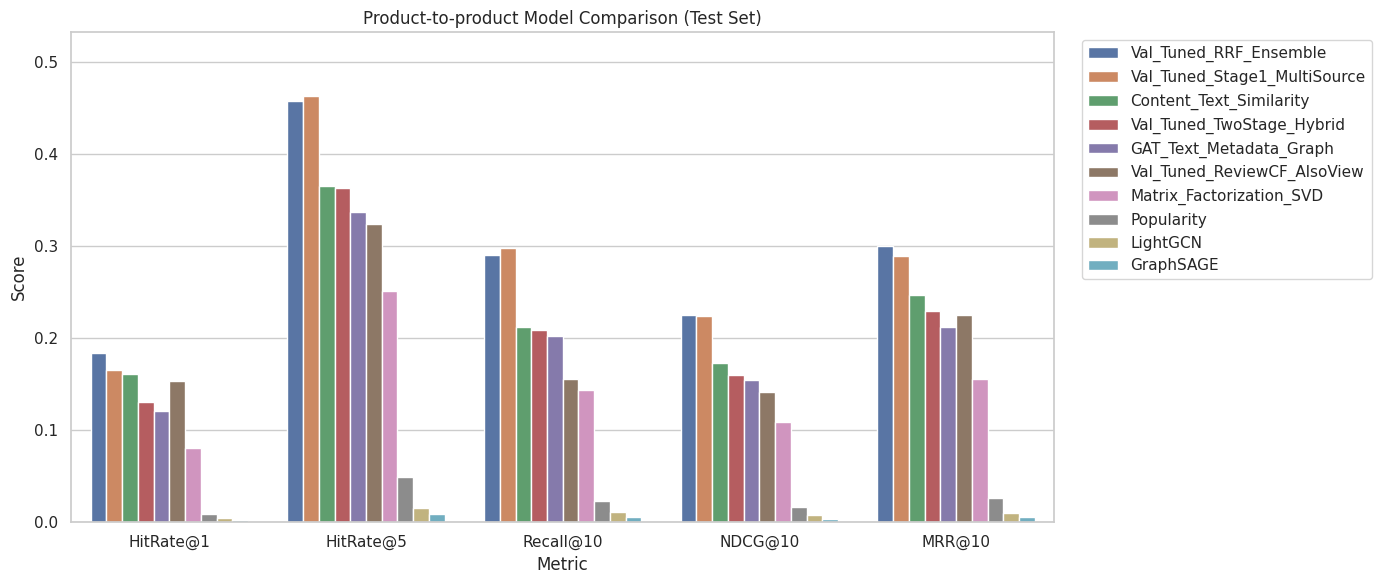

In [23]:
display(Markdown("### Product-to-product validation-set model comparison"))
display(product_val_results_df)

display(Markdown("### Product-to-product test-set model comparison"))
display(product_results_df)

# I report the validation-selected winner and summarize its key test metrics.
selected_product_metrics = product_results_df.loc[best_product_model_name]
selected_product_summary = pd.DataFrame(
    {
        "section": ["Product-to-Product"],
        "selected_on": ["Validation"],
        "reported_on": ["Test"],
        "best_model": [best_product_model_name],
        "serving_model": [best_product_serving_model_name],
        "hit_rate_at_10": [float(selected_product_metrics["HitRate@10"])],
        "ndcg_at_10": [float(selected_product_metrics["NDCG@10"])],
        "mrr_at_10": [float(selected_product_metrics["MRR@10"])],
    }
)
display(Markdown("### Final selected product-to-product model"))
display(selected_product_summary)

# I also reshape the results so I can compare the models visually across several ranking metrics.
metric_columns = ["HitRate@1", "HitRate@5", "Recall@10", "NDCG@10", "MRR@10"]
plot_df = product_results_df[metric_columns].reset_index().rename(columns={"index": "Model"})
plot_long = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_long, x="Metric", y="Score", hue="Model")
plt.title("Product-to-product Model Comparison (Test Set)")
plt.ylim(0, min(1.0, float(plot_long["Score"].max() * 1.15)))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Qualitative Recommendation Example

In this block, I inspect one query product and its recommendations so I can see what the selected model is retrieving.


In [24]:
# I pick a query product that has held-out targets so the example is informative.
queries_with_targets = [node for node, targets in test_ground_truth.items() if len(targets) > 0]
example_query_node = max(queries_with_targets, key=lambda node: len(test_ground_truth[node]))
best_model_name = best_product_model_name
best_ranker = best_product_ranker
serving_model_name = best_product_serving_model_name
serving_ranker = best_product_serving_ranker

# This helper collects the query product, the model recommendations, and the held-out ground truth in one place.
def recommendation_table(query_node, ranker, k=10):
    recommended_nodes = ranker(query_node, k)
    query_row = product_df.loc[product_df["node_id"] == query_node].iloc[0]
    recommended_rows = (
        product_df.loc[product_df["node_id"].isin(recommended_nodes), ["node_id", "asin", "title", "brand", "top_category"]]
        .set_index("node_id")
        .loc[list(recommended_nodes)]
        .reset_index(drop=True)
    )
    ground_truth_rows = (
        product_df.loc[product_df["node_id"].isin(test_ground_truth[query_node]), ["asin", "title", "brand", "top_category"]]
        .reset_index(drop=True)
    )
    return query_row, recommended_rows, ground_truth_rows

query_row, recommended_rows, ground_truth_rows = recommendation_table(example_query_node, best_ranker, k=10)
_, serving_recommended_rows, _ = recommendation_table(example_query_node, serving_ranker, k=10)

display(Markdown(f"### Example query product ({best_model_name})"))
query_display = query_row[["asin", "title", "brand", "top_category", "review_count", "avg_rating", "graph_degree"]].to_frame().T
query_display["train_buy_degree"] = train_buy_degree[example_query_node]
query_display["support_graph_degree"] = support_degree[example_query_node]
display(query_display)
display(Markdown("**Top recommendations from the benchmark-selected model**"))
display(recommended_rows)
display(Markdown(f"**Top recommendations after diversity-aware product serving ({serving_model_name})**"))
display(serving_recommended_rows)
display(Markdown("**Held-out ground truth products**"))
display(ground_truth_rows.head(10))


### Example query product (Val_Tuned_Stage1_MultiSource)

,asin,title,brand,top_category,review_count,avg_rating,graph_degree,train_buy_degree,support_graph_degree
429,B00H2AAXMQ,Lily's Dark Chocolate Chips- 1x9 OZ,Lily`s Sweets,Grocery & Gourmet Food,1000,4.021,473,306.0,324.0


**Top recommendations from the benchmark-selected model**

,asin,title,brand,top_category
0,B01G4I8WCE,"Lakanto Maple Flavored Sugar-Free Syrup, 1 Net Carb (Maple Syrup, 13 oz)",Lakanto,Grocery & Gourmet Food
1,B00IDLV6OM,"Almond Flour Blanched (2lb) by Anthony's, Batch Tested Gluten-Free",Anthony's,Grocery & Gourmet Food
2,B005YVU6FY,Carbquik Baking Biscuit Mix (48oz),Carbquik,Grocery & Gourmet Food
3,B004X73DAU,"Swerve Sweetener, Confectioners, 12 oz",Swerve,Grocery & Gourmet Food
4,B003BWNEWK,"HERSHEY'S Kitchens Holiday Baking Chips, Sugar Free Chocolate Chips, 8 Ounce Bag",HERSHEY'S,Grocery & Gourmet Food
5,B001YJ2VOO,"Utz Pork Rinds, Original Flavor &ndash; Gluten Free and Keto Friendly Snack with Zero Carbs per Serving, Light and Airy Chicharrones wit...",UTZ,Grocery & Gourmet Food
6,B0079OL6T4,"Lakanto Monkfruit 1:1 Sugar Substitute | 28 oz Non GMO (Golden, 800 g)",Lakanto,Grocery & Gourmet Food
7,B015SAX8ZA,Sukrin Fiber Syrup Gold,Sukrin,Grocery & Gourmet Food
8,B014V10S4Q,Lifesource Foods Oat Fiber 500 - 16 oz,LifeSource,Grocery & Gourmet Food
9,B01G4I8VGQ,"Lakanto Drinking Chocolate, 1 Net Carb, 10 Ounce",Lakanto,Grocery & Gourmet Food


**Top recommendations after diversity-aware product serving (Val_Tuned_Stage1_MultiSource + Diversity Post-Processing)**

,asin,title,brand,top_category
0,B01G4I8WCE,"Lakanto Maple Flavored Sugar-Free Syrup, 1 Net Carb (Maple Syrup, 13 oz)",Lakanto,Grocery & Gourmet Food
1,B00IDLV6OM,"Almond Flour Blanched (2lb) by Anthony's, Batch Tested Gluten-Free",Anthony's,Grocery & Gourmet Food
2,B005YVU6FY,Carbquik Baking Biscuit Mix (48oz),Carbquik,Grocery & Gourmet Food
3,B004X73DAU,"Swerve Sweetener, Confectioners, 12 oz",Swerve,Grocery & Gourmet Food
4,B003BWNEWK,"HERSHEY'S Kitchens Holiday Baking Chips, Sugar Free Chocolate Chips, 8 Ounce Bag",HERSHEY'S,Grocery & Gourmet Food
5,B001YJ2VOO,"Utz Pork Rinds, Original Flavor &ndash; Gluten Free and Keto Friendly Snack with Zero Carbs per Serving, Light and Airy Chicharrones wit...",UTZ,Grocery & Gourmet Food
6,B0079OL6T4,"Lakanto Monkfruit 1:1 Sugar Substitute | 28 oz Non GMO (Golden, 800 g)",Lakanto,Grocery & Gourmet Food
7,B015SAX8ZA,Sukrin Fiber Syrup Gold,Sukrin,Grocery & Gourmet Food
8,B014V10S4Q,Lifesource Foods Oat Fiber 500 - 16 oz,LifeSource,Grocery & Gourmet Food
9,B01G4I8VGQ,"Lakanto Drinking Chocolate, 1 Net Carb, 10 Ounce",Lakanto,Grocery & Gourmet Food


**Held-out ground truth products**

,asin,title,brand,top_category
0,B007JINB0W,"Miracle Noodle Zero Carb, Gluten Free Shirataki Pasta, Spinach Angel Hair, 7-Ounce (Pack of 24)",Miracle Noodle,Grocery & Gourmet Food
1,B00ARABK20,"PUR Gum, Spearmint, 55 pieces - Aspartame Free, Sugar Free, 100% Xylitol, Natural Chewing Gum, Non GMO, Vegan",The PUR Company,Grocery & Gourmet Food
2,B0079OL6T4,"Lakanto Monkfruit 1:1 Sugar Substitute | 28 oz Non GMO (Golden, 800 g)",Lakanto,Grocery & Gourmet Food
3,B005TKVU64,"XyloSweet Non-GMO Xylitol Natural Sweetener, Granules, 5lb Resealable",Xlear,Grocery & Gourmet Food
4,B000BD0SDU,"REDMOND Real Sea Salt - Natural Unrefined Organic Gluten Free Fine, 26 ounce pouch (1 Pack)",REDMOND,Grocery & Gourmet Food
5,B000ORSIJ4,"XyloSweet Non-GMO Xylitol Natural Sweetener, Granules, 5lb Resealable",Xlear,Grocery & Gourmet Food
6,B00TT6LEU6,"Sweetleaf Stevia 70 Piece Sweetener, 1 Count",SweetLeaf,Grocery & Gourmet Food
7,B0176REM6C,"People's Choice Beef Jerky - Old Fashioned - Original - Sugar-Free, Carb-Free, Keto-Friendly - 1 Pound, 1 Bag",People's Choice Beef Jerky,Grocery & Gourmet Food
8,B004EKHMXU,"Healthworks Cacao Nibs Organic, 1lb",Healthworks,Grocery & Gourmet Food
9,B0055IRNAC,"Almond Flour Blanched, Anthony's 4lb Bag, Batch Tested Gluten-Free",Anthony's,Grocery & Gourmet Food


### Low-Degree Query Evaluation

In this block, I evaluate low-degree query products so I can see how the models behave when train graph support is limited.


In [25]:
# I define the sparse-graph slice using the train also_buy degree of each test query.
low_degree_queries = [
    node for node, targets in test_ground_truth.items()
    if len(targets) > 0 and train_buy_degree[node] <= 1
]

if low_degree_queries:
    cold_start_slice = {}
    for model_name, ranker in rankers.items():
        cold_start_slice[model_name] = ranking_metrics_for_queries(
            ground_truth=test_ground_truth,
            ranker=ranker,
            topk_values=TOPK_VALUES,
            query_subset=low_degree_queries,
        )
    cold_start_results_df = pd.DataFrame(cold_start_slice).T.sort_values("NDCG@10", ascending=False)
    display(Markdown("### Product-to-product low-degree / cold-start-like evaluation"))
    display(cold_start_results_df)
else:
    print("No low-degree test queries were available in this split.")


### Product-to-product low-degree / cold-start-like evaluation

,HitRate@1,Recall@1,NDCG@1,MRR@1,HitRate@5,Recall@5,NDCG@5,MRR@5,HitRate@10,Recall@10,NDCG@10,MRR@10,HitRate@20,Recall@20,NDCG@20,MRR@20
Content_Text_Similarity,0.192,0.148333,0.192,0.192,0.396,0.346333,0.269535,0.270667,0.464,0.412333,0.292515,0.279449,0.540,0.480333,0.311543,0.284566
Val_Tuned_RRF_Ensemble,0.172,0.135667,0.172,0.172,0.376,0.320333,0.245954,0.247467,0.496,0.433000,0.285584,0.263649,0.576,0.519333,0.309496,0.269397
Val_Tuned_Stage1_MultiSource,0.140,0.117000,0.140,0.140,0.424,0.361000,0.255542,0.240800,0.496,0.435667,0.281601,0.250441,0.584,0.525000,0.307174,0.256828
Val_Tuned_ReviewCF_AlsoView,0.188,0.152333,0.188,0.188,0.300,0.257000,0.222522,0.235267,0.324,0.281000,0.230319,0.238281,0.380,0.324333,0.242285,0.242432
Val_Tuned_TwoStage_Hybrid,0.056,0.050000,0.056,0.056,0.248,0.213000,0.134949,0.117600,0.340,0.302333,0.165278,0.129956,0.436,0.394000,0.190166,0.136301
GAT_Text_Metadata_Graph,0.044,0.035333,0.044,0.044,0.164,0.140000,0.090860,0.081933,0.196,0.172000,0.102445,0.086497,0.280,0.248667,0.123555,0.092283
Matrix_Factorization_SVD,0.044,0.037333,0.044,0.044,0.116,0.098667,0.071684,0.068333,0.164,0.135333,0.084159,0.074127,0.216,0.184000,0.097854,0.077863
LightGCN,0.008,0.008000,0.008,0.008,0.028,0.024000,0.017330,0.015667,0.032,0.028000,0.018663,0.016238,0.036,0.032000,0.019663,0.016505
GraphSAGE,0.012,0.012000,0.012,0.012,0.020,0.018000,0.015547,0.015333,0.020,0.018000,0.015547,0.015333,0.028,0.022000,0.016749,0.015835
Popularity,0.004,0.002000,0.004,0.004,0.004,0.002000,0.002453,0.004000,0.004,0.002000,0.002453,0.004000,0.008,0.006000,0.003431,0.004250


### Final Leaderboard

In this block, I create a compact final table and leaderboard so I can report the selected model and the overall ranking results clearly.


In [26]:
# I build one compact table for the selected model and one leaderboard for all test-set models.
selected_product_metrics = product_results_df.loc[best_product_model_name]

final_product_model_table = pd.DataFrame(
    {
        "section": ["Product-to-Product"],
        "selected_on": ["Validation NDCG@10"],
        "reported_on": ["Held-out test split"],
        "best_model": [best_product_model_name],
        "serving_model": [best_product_serving_model_name],
        "hit_rate_at_10": [float(selected_product_metrics["HitRate@10"])],
        "recall_at_10": [float(selected_product_metrics["Recall@10"])],
        "ndcg_at_10": [float(selected_product_metrics["NDCG@10"])],
        "mrr_at_10": [float(selected_product_metrics["MRR@10"])],
    }
)

final_test_leaderboard = (
    product_results_df
    .reset_index()
    .rename(columns={"index": "model"})
    [["model", "HitRate@10", "Recall@10", "NDCG@10", "MRR@10"]]
    .sort_values("NDCG@10", ascending=False)
)

display(Markdown("### Validation-selected best product-to-product model"))
display(final_product_model_table)

display(Markdown("### Final held-out test leaderboard"))
display(final_test_leaderboard)


### Validation-selected best product-to-product model

,section,selected_on,reported_on,best_model,serving_model,hit_rate_at_10,recall_at_10,ndcg_at_10,mrr_at_10
0,Product-to-Product,Validation NDCG@10,Held-out test split,Val_Tuned_Stage1_MultiSource,Val_Tuned_Stage1_MultiSource + Diversity Post-Processing,0.588303,0.298306,0.224193,0.288939


### Final held-out test leaderboard

,model,HitRate@10,Recall@10,NDCG@10,MRR@10
0,Val_Tuned_RRF_Ensemble,0.585894,0.290645,0.224750,0.300295
1,Val_Tuned_Stage1_MultiSource,0.588303,0.298306,0.224193,0.288939
2,Content_Text_Similarity,0.454702,0.212272,0.173242,0.247399
3,Val_Tuned_TwoStage_Hybrid,0.486009,0.208632,0.160246,0.229383
4,GAT_Text_Metadata_Graph,0.443807,0.202311,0.154790,0.212307
5,Val_Tuned_ReviewCF_AlsoView,0.381537,0.156166,0.141469,0.225757
6,Matrix_Factorization_SVD,0.360550,0.143193,0.108539,0.155843
7,Popularity,0.077867,0.023314,0.016480,0.026021
8,LightGCN,0.022821,0.010621,0.007438,0.009554
9,GraphSAGE,0.016055,0.005194,0.003856,0.005715
